In [151]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss
from sarima import plot_target

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


In [152]:
df = pd.read_csv('Updated Data/disaggregated_updated.csv')
first_col = df.columns[0]
df[first_col] = pd.to_datetime(df[first_col], errors='coerce')
df = df.rename(columns={"Unnamed: 3": "Date"})
df.set_index("Date", inplace=True)

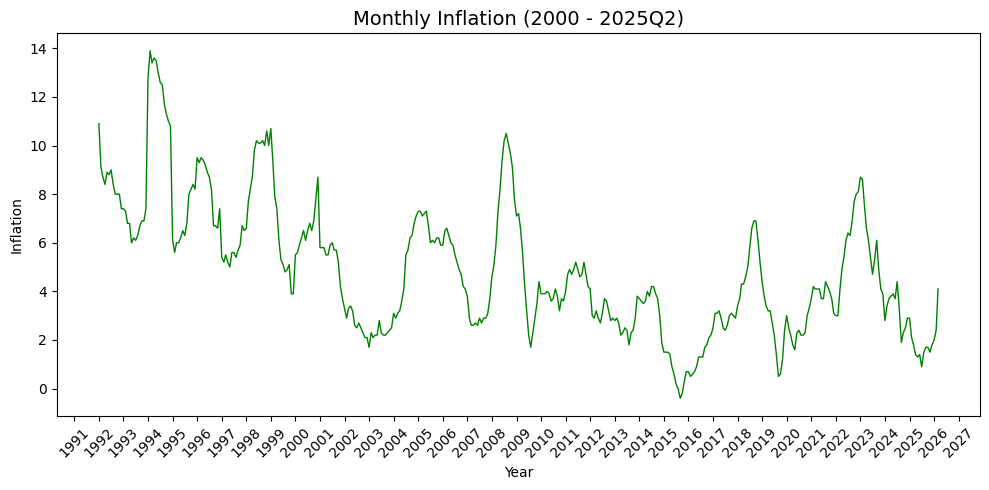

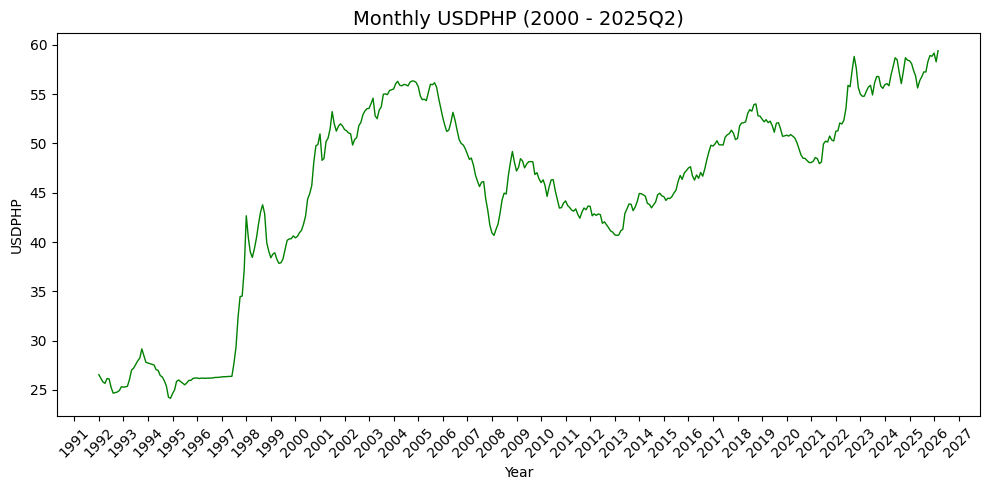

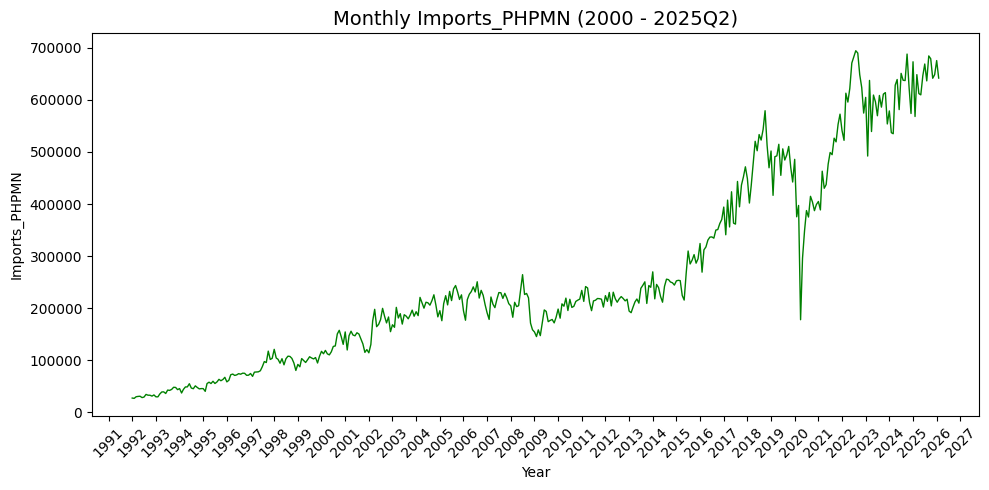

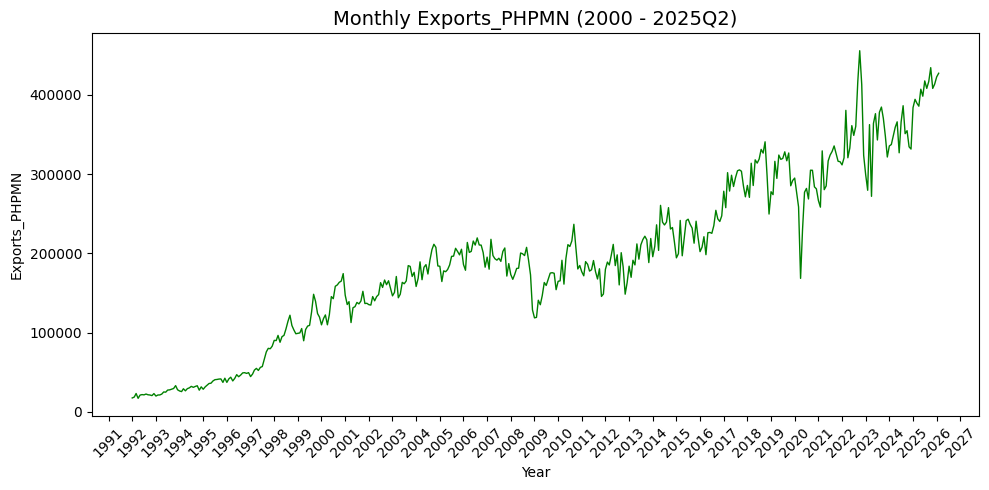

In [153]:
cols = ["Inflation", "USDPHP", "Imports_PHPMN", "Exports_PHPMN"]
test_num = int(len(df) * 0.20)
train_size = len(df) - test_num

train = df.iloc[:train_size][cols].reset_index().copy()
test = df.iloc[train_size:][cols].reset_index().copy()

train_plot = train.set_index("Date")
test_plot = test.set_index("Date")

for col in cols:
    plot_target(df, col, color="green")


In [154]:
LABEL_COLS = ["Inflation", "USDPHP", "Imports_PHPMN", "Exports_PHPMN"]

records = []

for x in LABEL_COLS:
    s = pd.to_numeric(train[x], errors="coerce")

    level = adfuller(s.dropna(), autolag="AIC")
    first_diff = adfuller(s.diff().dropna(), autolag="AIC")
    second_diff = adfuller(s.diff().diff().dropna(), autolag="AIC")
    seasonal_diff = adfuller(s.diff(12).dropna(), autolag="AIC")
    seasonal_double_diff = adfuller(s.diff().diff(12).dropna(), autolag="AIC")

    records.append({
        "Variable": x,
        "Level p-value": round(level[1], 4),
        "Level Stationary": level[1] < 0.05,
        "First Diff p-value": round(first_diff[1], 4),
        "First Diff Stationary": first_diff[1] < 0.05,
        "Second Diff p-value": round(second_diff[1], 4),
        "Second Diff Stationary": second_diff[1] < 0.05,
        "Seasonal Diff p-value": round(seasonal_diff[1], 4),
        "Seasonal Diff Stationary": seasonal_diff[1] < 0.05,
        "Seasonal Double Diff p-value": round(seasonal_double_diff[1], 4),
        "Seasonal Double Diff Stationary": seasonal_double_diff[1] < 0.05,
    })

stationarity_df = pd.DataFrame(records).set_index("Variable")
stationarity_df

,Level p-value,Level Stationary,First Diff p-value,First Diff Stationary,Second Diff p-value,Second Diff Stationary,Seasonal Diff p-value,Seasonal Diff Stationary,Seasonal Double Diff p-value,Seasonal Double Diff Stationary
Variable,,,,,,,,,,
Inflation,0.2868,False,0.0000,True,0.0,True,0.0000,True,0.0,True
USDPHP,0.4640,False,0.0000,True,0.0,True,0.0399,True,0.0,True
Imports_PHPMN,0.9960,False,0.0001,True,0.0,True,0.2838,False,0.0,True
Exports_PHPMN,0.9001,False,0.0000,True,0.0,True,0.0018,True,0.0,True


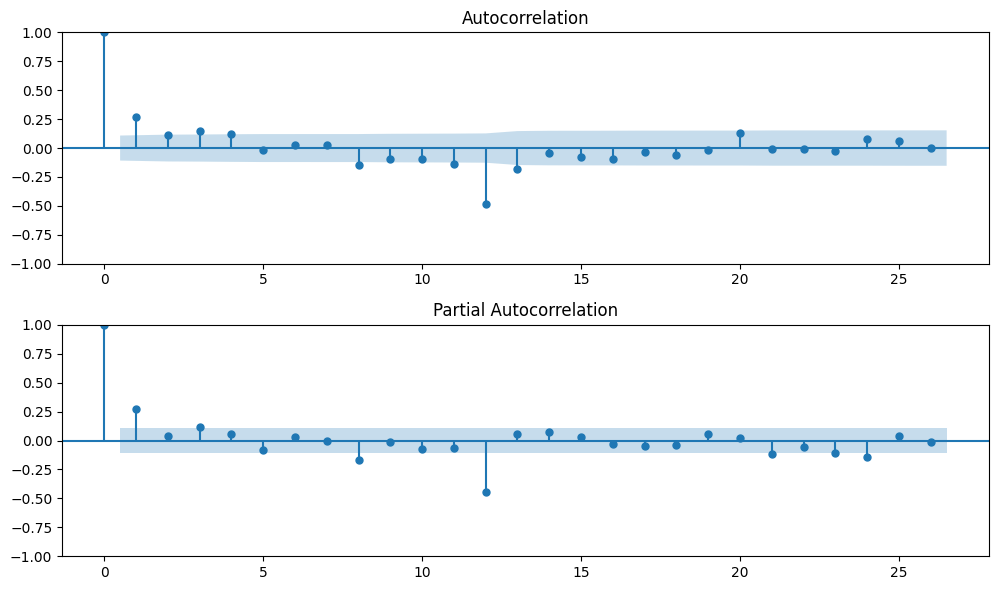

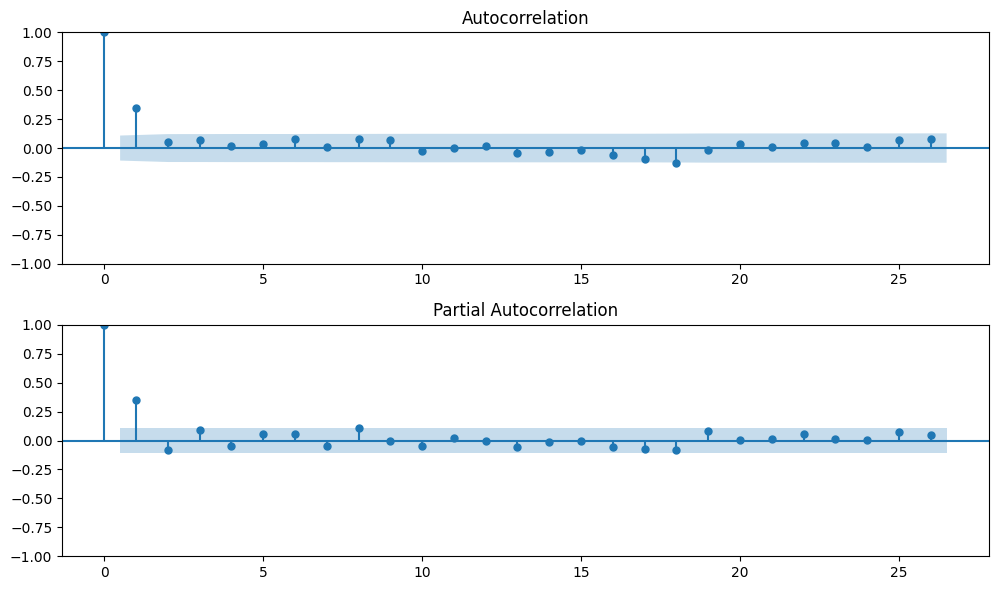

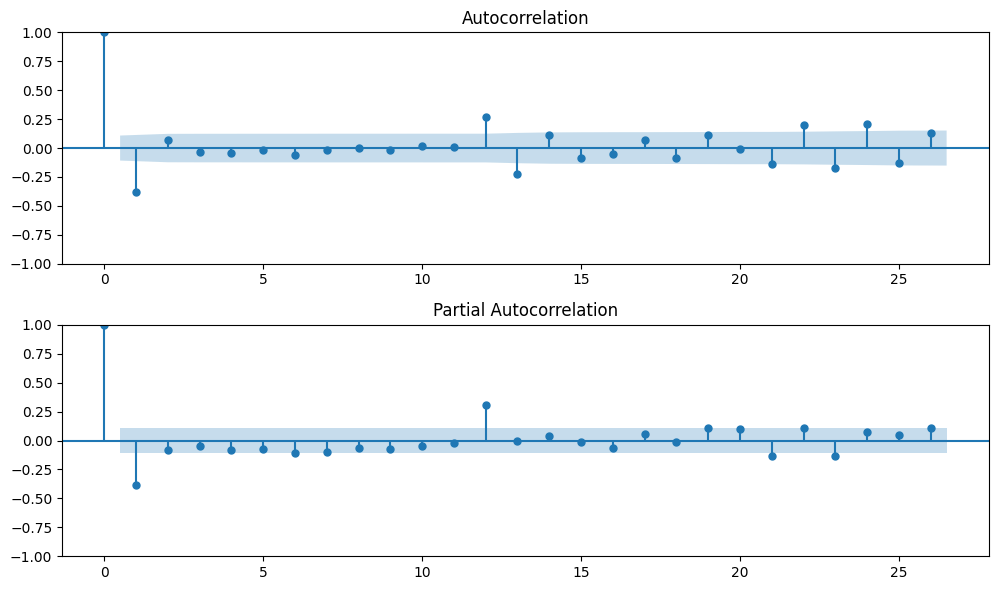

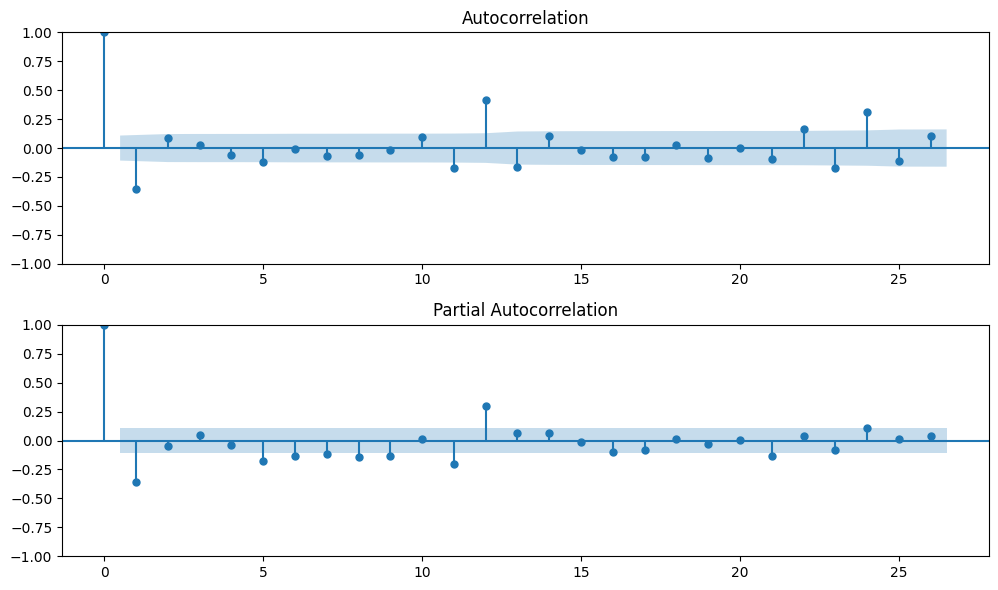

In [155]:
diff_inflation = train["Inflation"].diff().dropna()
diff_usdphp = train["USDPHP"].diff().dropna()
diff_imports = train["Imports_PHPMN"].diff().dropna()
diff_exports = train["Exports_PHPMN"].diff().dropna()

fig, ax = plt.subplots(2, 1, figsize=(10, 6))
plot_acf(diff_inflation.dropna(), ax=ax[0])
plot_pacf(diff_inflation.dropna(), ax=ax[1])
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(2, 1, figsize=(10, 6))
plot_acf(diff_usdphp.dropna(), ax=ax[0])
plot_pacf(diff_usdphp.dropna(), ax=ax[1])
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(2, 1, figsize=(10, 6))
plot_acf(diff_imports.dropna(), ax=ax[0])
plot_pacf(diff_imports.dropna(), ax=ax[1])
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(2, 1, figsize=(10, 6))
plot_acf(diff_exports.dropna(), ax=ax[0])
plot_pacf(diff_exports.dropna(), ax=ax[1])
plt.tight_layout()
plt.show()

In [156]:
import os
from sarima import multitarget_sarima

bounds_map = {
    "Inflation":  {"p_min": 0, "p_max": 1, "d_min":1, "d_max": 1, "q_min": 0, "q_max": 2, "P_min": 0, "P_max": 1, "D_min": 0, "D_max": 1, "Q_min": 0, "Q_max": 1},
    "USDPHP": {"p_min": 0, "p_max": 1, "d_min":1, "d_max": 1, "q_min": 0, "q_max": 1, "P_min": 0, "P_max": 1, "D_min": 0, "D_max": 1, "Q_min": 0, "Q_max": 1},
    "Imports_PHPMN": {"p_min": 0, "p_max": 1, "d_min":2, "d_max": 2, "q_min": 0, "q_max": 1, "P_min": 0, "P_max": 1, "D_min": 0, "D_max": 1, "Q_min": 0, "Q_max": 1},
    "Exports_PHPMN": {"p_min": 0, "p_max": 1, "d_min":1, "d_max": 1, "q_min": 0, "q_max": 1, "P_min": 0, "P_max": 1, "D_min": 0, "D_max": 1, "Q_min": 0, "Q_max": 1},
}

labels = LABEL_COLS

train_sarima = train.set_index("Date")[labels].apply(pd.to_numeric, errors="coerce").sort_index()
test_sarima = test.set_index("Date")[labels].apply(pd.to_numeric, errors="coerce").sort_index()

# Explicit monthly frequency avoids repeated statsmodels DateIndex warnings.
train_sarima = train_sarima.asfreq("MS")
test_sarima = test_sarima.asfreq("MS")

# Prevent metric failures inside multitarget_sarima when source data has gaps.
train_sarima = train_sarima.interpolate(method="time").ffill().bfill()
test_sarima = test_sarima.interpolate(method="time").ffill().bfill()

test_index = pd.to_datetime(test_sarima.index)
forecasts_df = pd.DataFrame(index=test_index)
fitted_models = {}
all_best_dfs = []
all_trial_dfs = []

for label in labels:
    lbl_best, lbl_trials, lbl_forecasts, lbl_models = multitarget_sarima(
        train_df=train_sarima,
        test_df=test_sarima,
        exog_train=None,
        exog_test=None,
        labels=[label],
        bounds_map=bounds_map,
        seasonal_period=12,
        verbose=True,
        n_jobs=1,
    )

    all_best_dfs.append(lbl_best)
    all_trial_dfs.append(lbl_trials)

    lbl_forecasts = lbl_forecasts.copy()
    lbl_forecasts.index = pd.to_datetime(lbl_forecasts.index)

    for col in lbl_forecasts.columns:
        aligned = lbl_forecasts[col].reindex(test_index)
        forecasts_df[col] = aligned.values

    fitted_models.update(lbl_models)

best_models_df = pd.concat(all_best_dfs)
all_trials_df = pd.concat(all_trial_dfs, ignore_index=True)

display(best_models_df)
display(forecasts_df.head())

Inflation grid:   0%|          | 0/6 [00:00<?, ?it/s]

[Inflation] candidates: 48


USDPHP grid:   0%|          | 0/4 [00:00<?, ?it/s]           

[USDPHP] candidates: 32


Imports_PHPMN grid:   0%|          | 0/4 [00:00<?, ?it/s] 

[Imports_PHPMN] candidates: 32


Exports_PHPMN grid:   0%|          | 0/4 [00:00<?, ?it/s]        

[Exports_PHPMN] candidates: 32


,Best_Order,Best_Seasonal_Order,Best_AIC,MAE,RMSE,MAPE_pct
Target,,,,,,
Inflation,"(1, 1, 2)","(0, 0, 1, 12)",473.708855,1.427810,1.932504,45.471250
USDPHP,"(0, 1, 1)","(0, 1, 1, 12)",705.611430,2.391359,3.092422,4.676374
Imports_PHPMN,"(1, 2, 1)","(0, 1, 1, 12)",6820.603200,170358.871029,188016.850264,33.666070
Exports_PHPMN,"(0, 1, 1)","(0, 1, 1, 12)",6585.973527,31884.925714,41138.520020,10.596962


,Inflation,USDPHP,Imports_PHPMN,Exports_PHPMN
Date,,,,
2019-06-01,3.081029,52.725623,508709.118753,318031.786794
2019-07-01,2.567730,52.984453,526293.927676,322850.372586
2019-08-01,1.964470,53.158271,534995.441433,326319.306945
2019-09-01,1.469908,53.483027,536228.313284,332738.033638
2019-10-01,1.366771,53.602278,547510.241249,327903.454873


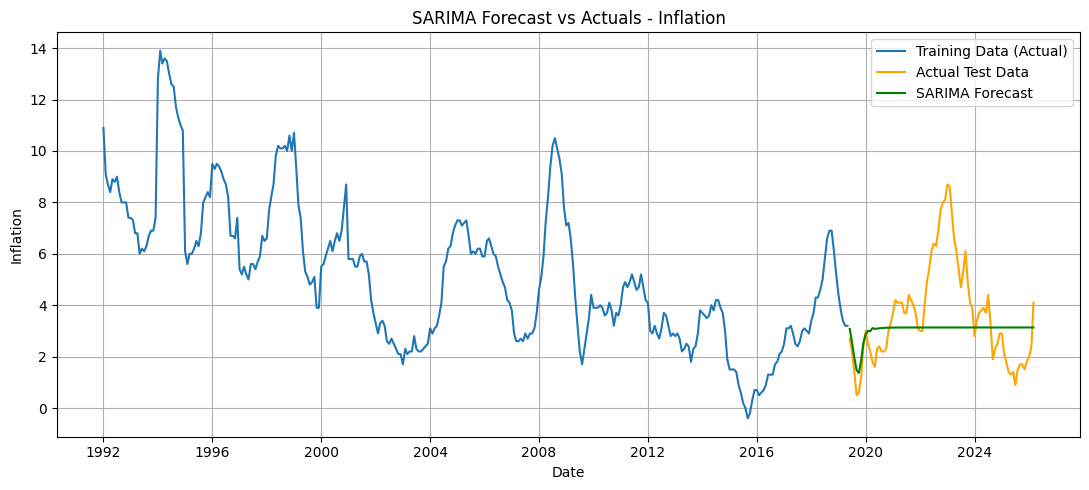

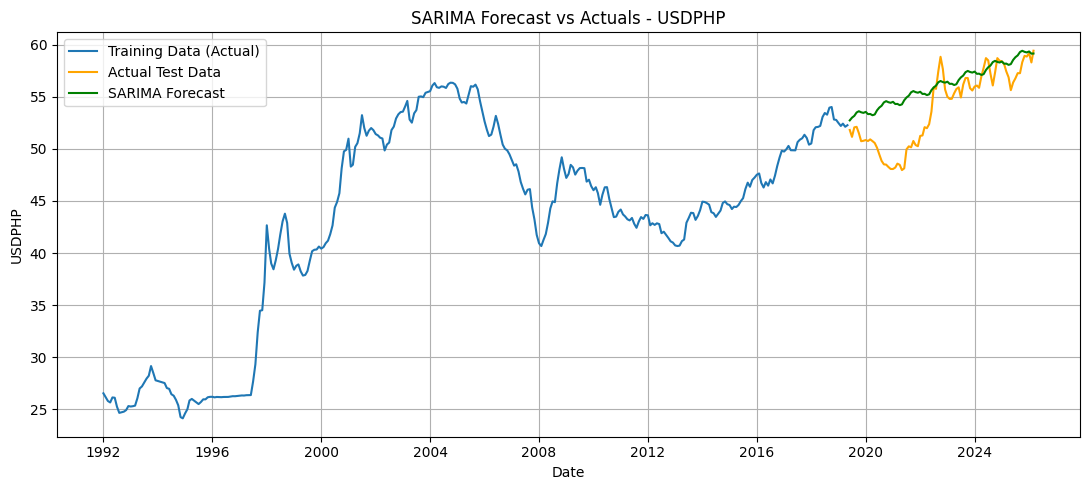

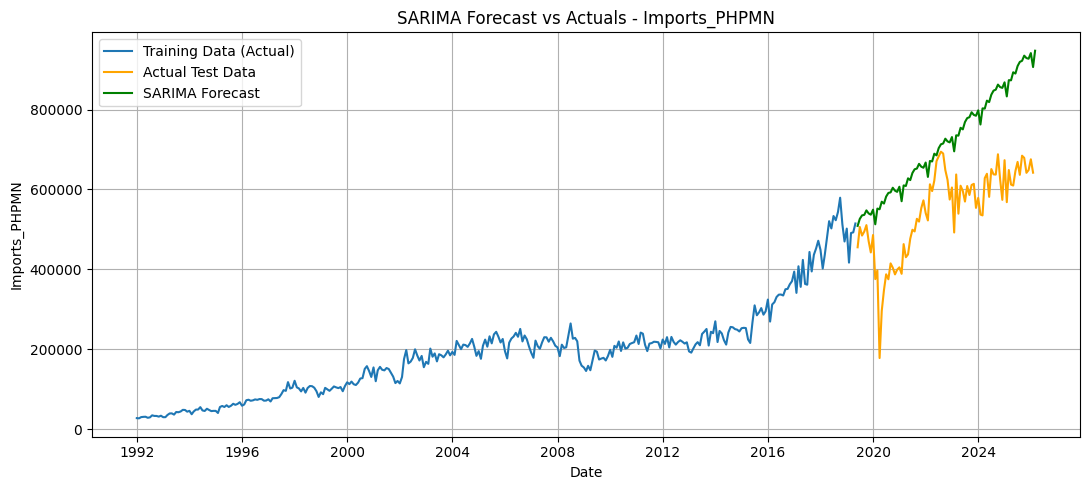

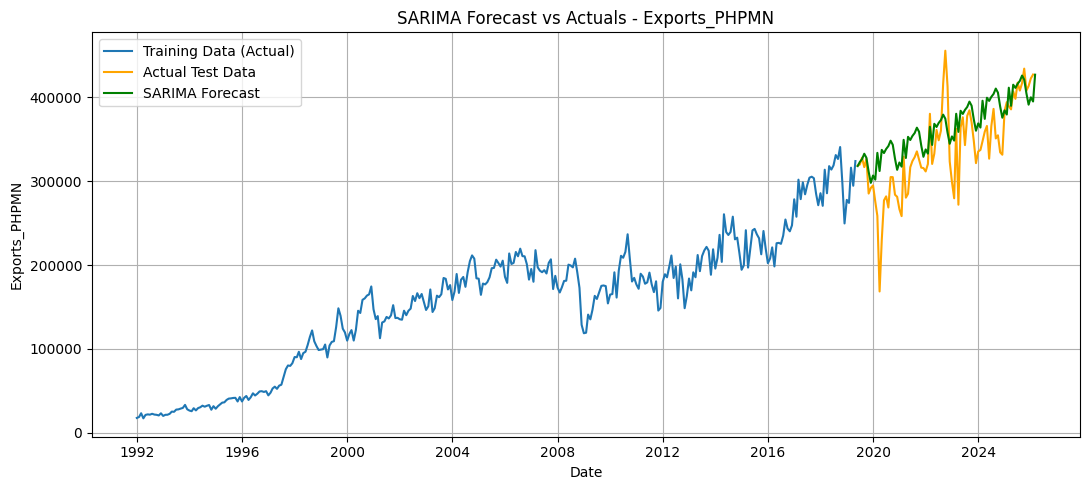

In [157]:
train_eval = train.set_index("Date").copy()
test_eval = test.set_index("Date").copy()

train_eval.index = pd.to_datetime(train_eval.index)
test_eval.index = pd.to_datetime(test_eval.index)

labels_to_plot = [
    lbl for lbl in labels
    if lbl in train_eval.columns and lbl in test_eval.columns and lbl in forecasts_df.columns
]

if not labels_to_plot:
    raise ValueError("No matching labels found across train/test/forecasts_df.")

for lbl in labels_to_plot:
    plt.figure(figsize=(11, 5))
    plt.plot(train_eval.index, train_eval[lbl], label="Training Data (Actual)")
    plt.plot(test_eval.index, test_eval[lbl], label="Actual Test Data", color="orange")
    plt.plot(forecasts_df.index, forecasts_df[lbl], label="SARIMA Forecast", color="green")
    plt.title(f"SARIMA Forecast vs Actuals - {lbl}")
    plt.xlabel("Date")
    plt.ylabel(lbl)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    

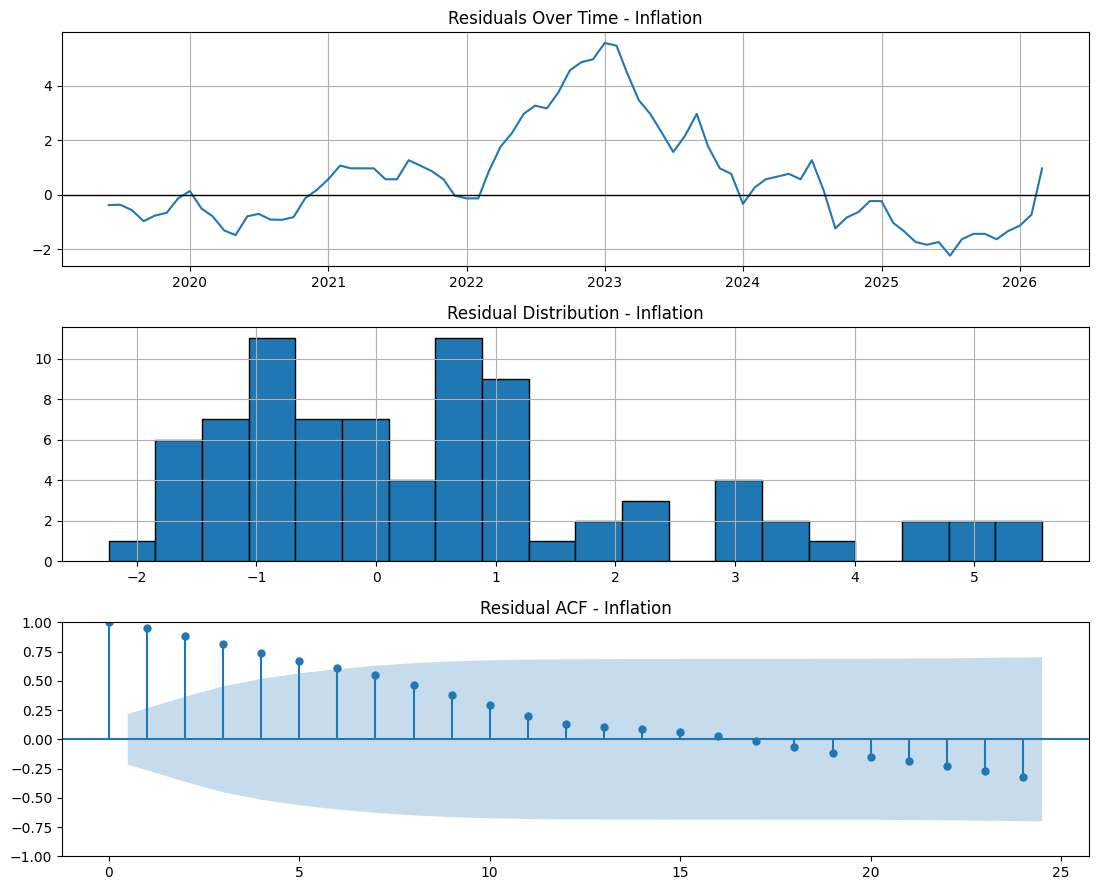

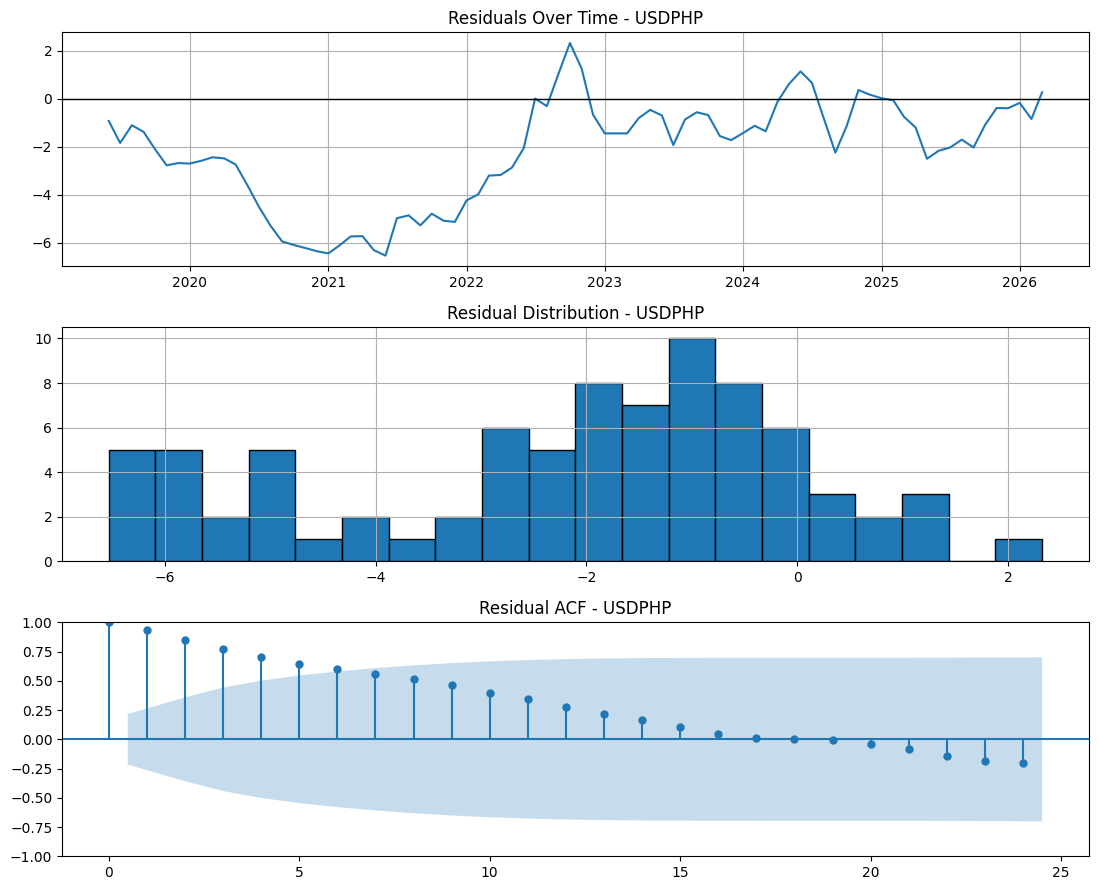

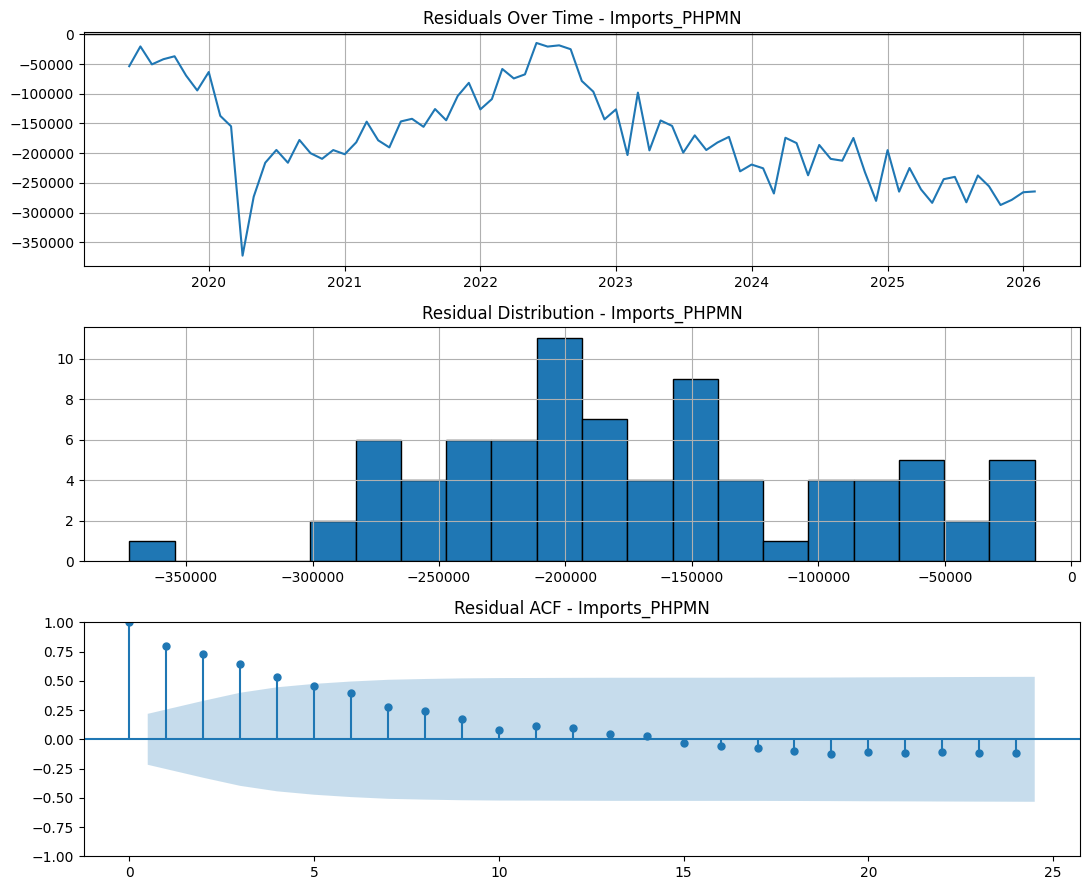

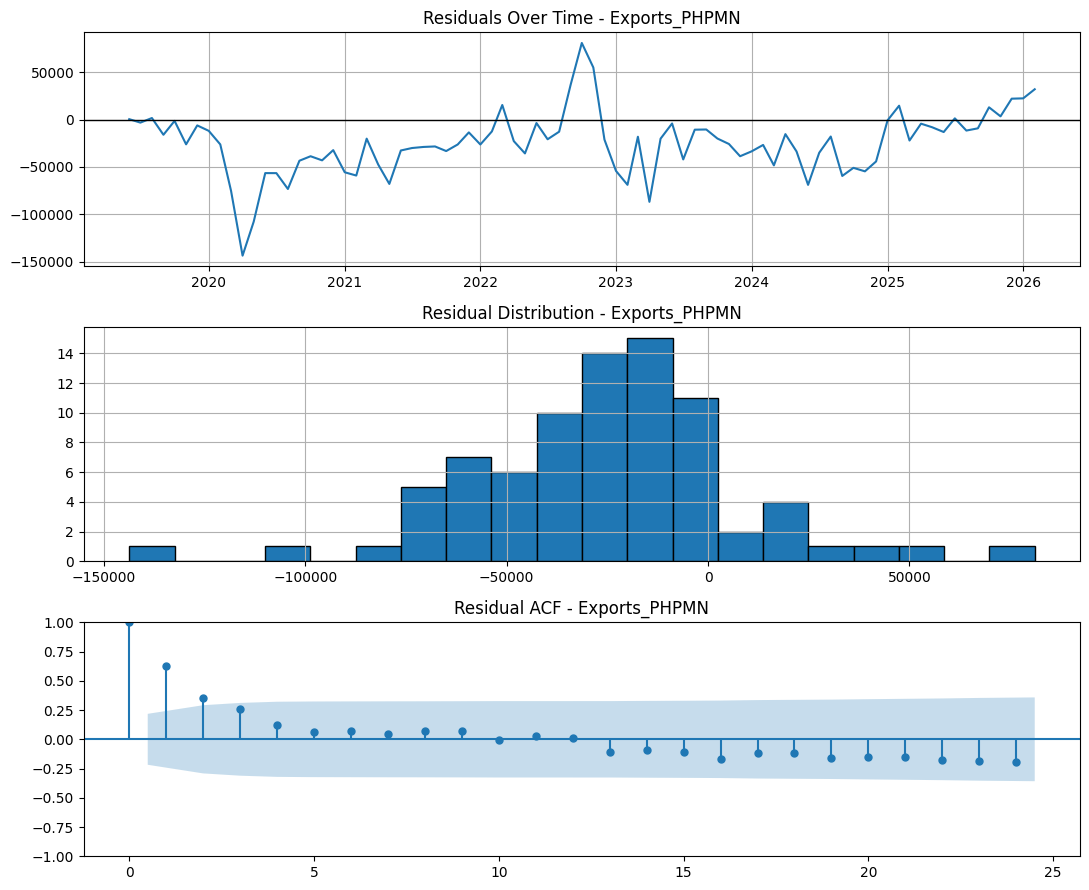

,n_obs,Mean Residual,Std Residual,Ljung-Box p-value (lag 12),No Residual Autocorr (5%),Jarque-Bera p-value,Residual Normal (5%)
Variable,,,,,,,
Inflation,82,0.567510,1.858664,6.041334e-78,False,0.001248,False
USDPHP,82,-2.199316,2.187334,5.497844e-80,False,0.091623,True
Imports_PHPMN,81,-168692.904497,79094.655591,4.428801e-38,False,0.460165,True
Exports_PHPMN,81,-24848.757515,33309.277005,4.030799e-07,False,0.000203,False


In [158]:
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import jarque_bera

residual_records = []
residuals_df = pd.DataFrame(index=forecasts_df.index)

test_actual = test.set_index("Date").copy()
test_actual.index = pd.to_datetime(test_actual.index)

diag_labels = [
    lbl for lbl in labels
    if lbl in test_actual.columns and lbl in forecasts_df.columns
]

if not diag_labels:
    raise ValueError("No matching labels found for residual diagnostics.")

for lbl in diag_labels:
    actual = pd.to_numeric(test_actual[lbl], errors="coerce")
    pred = pd.to_numeric(forecasts_df[lbl], errors="coerce")

    resid = (actual - pred).dropna()
    residuals_df[lbl] = resid.reindex(residuals_df.index)

    lb_df = acorr_ljungbox(resid, lags=[12], return_df=True)
    jb_stat, jb_p = jarque_bera(resid)

    residual_records.append({
        "Variable": lbl,
        "n_obs": len(resid),
        "Mean Residual": resid.mean(),
        "Std Residual": resid.std(ddof=1),
        "Ljung-Box p-value (lag 12)": lb_df["lb_pvalue"].iloc[0],
        "No Residual Autocorr (5%)": lb_df["lb_pvalue"].iloc[0] > 0.05,
        "Jarque-Bera p-value": jb_p,
        "Residual Normal (5%)": jb_p > 0.05,
    })

    fig, ax = plt.subplots(3, 1, figsize=(11, 9))
    ax[0].plot(resid.index, resid.values)
    ax[0].axhline(0, color="black", linewidth=1)
    ax[0].set_title(f"Residuals Over Time - {lbl}")
    ax[0].grid(True)

    ax[1].hist(resid.values, bins=20, edgecolor="black")
    ax[1].set_title(f"Residual Distribution - {lbl}")
    ax[1].grid(True)

    plot_acf(resid, ax=ax[2], lags=24)
    ax[2].set_title(f"Residual ACF - {lbl}")

    plt.tight_layout()
    plt.show()

residual_diagnostics_df = pd.DataFrame(residual_records).set_index("Variable")
residual_diagnostics_df

In [159]:
import ast
from statsmodels.tsa.statespace.sarimax import SARIMAX

full_df = df[labels].apply(pd.to_numeric, errors="coerce").sort_index().asfreq("MS")
full_df = full_df.interpolate(method="time").ffill().bfill()

forecast_end = pd.Timestamp("2026-12-01")
last_obs = full_df.index.max()
future_index = pd.date_range(last_obs + pd.offsets.MonthBegin(1), forecast_end, freq="MS")

if len(future_index) == 0:
    raise ValueError("No future months to forecast: data already reaches or passes 2026-12.")

future_forecasts = pd.DataFrame(index=future_index)
future_models = {}

for lbl in labels:
    order = best_models_df.loc[lbl, "Best_Order"]
    seasonal_order = best_models_df.loc[lbl, "Best_Seasonal_Order"]

    # Handle tuple values stored as strings.
    if isinstance(order, str):
        order = ast.literal_eval(order)
    if isinstance(seasonal_order, str):
        seasonal_order = ast.literal_eval(seasonal_order)

    series = full_df[lbl]

    model = SARIMAX(
        series,
        order=tuple(order),
        seasonal_order=tuple(seasonal_order),
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    fit = model.fit(disp=False)

    pred = fit.get_forecast(steps=len(future_index)).predicted_mean
    pred.index = future_index

    future_forecasts[lbl] = pred.values
    future_models[lbl] = fit

future_forecasts

,Inflation,USDPHP,Imports_PHPMN,Exports_PHPMN
2026-04-01,4.944295,59.842900,638603.083558,405116.587106
2026-05-01,5.188258,59.895491,655293.262083,432653.523190
2026-06-01,5.428284,60.278082,660184.996065,435260.936830
2026-07-01,5.665252,60.544241,680366.877471,440452.278150
2026-08-01,5.560457,60.708288,680312.189590,446933.091724
2026-09-01,5.812286,60.989912,688512.033171,454503.460426
2026-10-01,5.872194,61.192062,694973.694639,457170.775045
2026-11-01,6.109065,61.066503,678334.864183,435398.936787
2026-12-01,5.743815,60.941106,663536.802070,421930.095520


In [160]:
# Evaluate test-set forecast errors per label.
metrics_records = []

test_eval = test.set_index("Date").copy()
test_eval.index = pd.to_datetime(test_eval.index)

metric_labels = [
    lbl for lbl in labels
    if lbl in test_eval.columns and lbl in forecasts_df.columns
]

for lbl in metric_labels:
    y_true = pd.to_numeric(test_eval[lbl], errors="coerce")
    y_pred = pd.to_numeric(forecasts_df[lbl], errors="coerce")

    comp = pd.concat([y_true, y_pred], axis=1, keys=["actual", "forecast"]).dropna()
    a = comp["actual"]
    f = comp["forecast"]
    err = a - f

    mae = np.mean(np.abs(err))
    rmse = np.sqrt(np.mean(err**2))

    mape = np.nan
    nz = a != 0
    if nz.any():
        mape = np.mean(np.abs((a[nz] - f[nz]) / a[nz])) * 100

    smape_denom = np.abs(a) + np.abs(f)
    smape_mask = smape_denom != 0
    smape = np.nan
    if smape_mask.any():
        smape = np.mean(2 * np.abs(a[smape_mask] - f[smape_mask]) / smape_denom[smape_mask]) * 100

    metrics_records.append({
        "Variable": lbl,
        "n_obs": len(comp),
        "MAE": mae,
        "RMSE": rmse,
        "MAPE_pct": mape,
        "sMAPE_pct": smape,
        "Mean_Error(actual-forecast)": err.mean(),
        "Mean_Abs_Error": np.mean(np.abs(err)),
    })

test_metrics_df = pd.DataFrame(metrics_records).set_index("Variable")
test_metrics_df

,n_obs,MAE,RMSE,MAPE_pct,sMAPE_pct,Mean_Error(actual-forecast),Mean_Abs_Error
Variable,,,,,,,
Inflation,82,1.427810,1.932504,45.471250,40.955098,0.567510,1.427810
USDPHP,82,2.391359,3.092422,4.676374,4.496577,-2.199316,2.391359
Imports_PHPMN,81,168692.904497,186107.566855,33.494456,27.191516,-168692.904497,168692.904497
Exports_PHPMN,81,32276.557288,41391.678582,10.727318,9.761120,-24848.757515,32276.557288


## Population

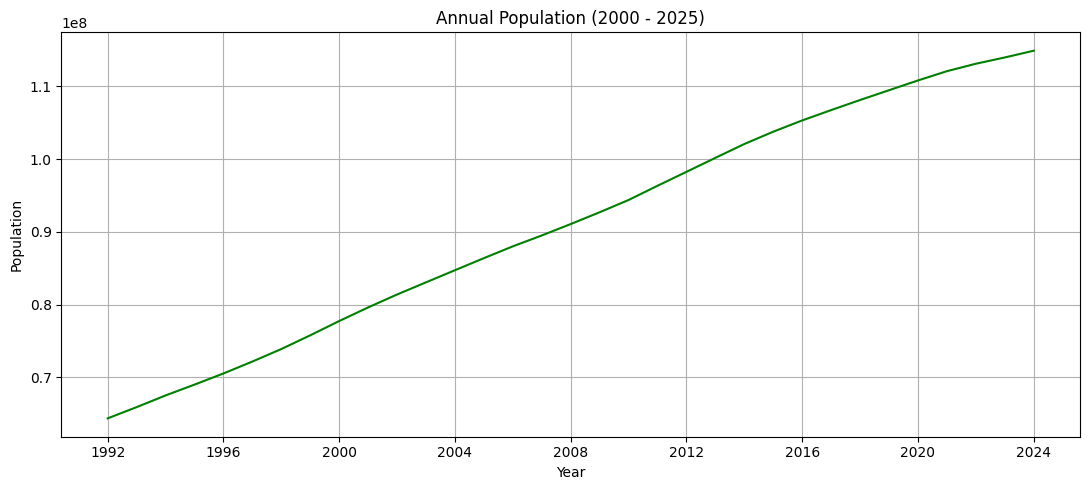

In [161]:
cols = ["Population"]

use_cols = [c for c in cols if c in df.columns]
if not use_cols:
    raise ValueError("Requested columns are not present in df.")

df_clean = df[use_cols].dropna(subset=["Population"]).copy()
if df_clean.empty:
    raise ValueError("No rows left after dropping NaN values in Population.")

# Population is treated as annual data.
df_clean.index = pd.to_datetime(df_clean.index).to_period("Y").to_timestamp()
df_clean = df_clean.groupby(df_clean.index).last().sort_index()

test_num = int(len(df_clean) * 0.20)
train_size = len(df_clean) - test_num

train = df_clean.iloc[:train_size].reset_index().copy()
test = df_clean.iloc[train_size:].reset_index().copy()
train = train.rename(columns={"index": "Date"})
test = test.rename(columns={"index": "Date"})

train_plot = train.set_index("Date")
test_plot = test.set_index("Date")

for col in use_cols:
    plt.figure(figsize=(11, 5))
    plt.plot(df_clean.index, df_clean[col], color="green", linewidth=1.5)
    plt.title(f"Annual {col} (2000 - 2025)")
    plt.xlabel("Year")
    plt.ylabel(col)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [162]:
LABEL_COLS = ["Population"]

records = []

for x in LABEL_COLS:
    s = pd.to_numeric(train[x], errors="coerce")

    level = adfuller(s.dropna(), autolag="AIC")
    first_diff = adfuller(s.diff().dropna(), autolag="AIC")
    second_diff = adfuller(s.diff().diff().dropna(), autolag="AIC")
    seasonal_diff = adfuller(s.diff(12).dropna(), autolag="AIC")
    seasonal_double_diff = adfuller(s.diff().diff(12).dropna(), autolag="AIC")

    records.append({
        "Variable": x,
        "Level p-value": round(level[1], 4),
        "Level Stationary": level[1] < 0.05,
        "First Diff p-value": round(first_diff[1], 4),
        "First Diff Stationary": first_diff[1] < 0.05,
        "Second Diff p-value": round(second_diff[1], 4),
        "Second Diff Stationary": second_diff[1] < 0.05,
        "Seasonal Diff p-value": round(seasonal_diff[1], 4),
        "Seasonal Diff Stationary": seasonal_diff[1] < 0.05,
        "Seasonal Double Diff p-value": round(seasonal_double_diff[1], 4),
        "Seasonal Double Diff Stationary": seasonal_double_diff[1] < 0.05,
    })

stationarity_df = pd.DataFrame(records).set_index("Variable")
stationarity_df

,Level p-value,Level Stationary,First Diff p-value,First Diff Stationary,Second Diff p-value,Second Diff Stationary,Seasonal Diff p-value,Seasonal Diff Stationary,Seasonal Double Diff p-value,Seasonal Double Diff Stationary
Variable,,,,,,,,,,
Population,0.9319,False,0.034,True,0.0193,True,0.6512,False,0.2142,False


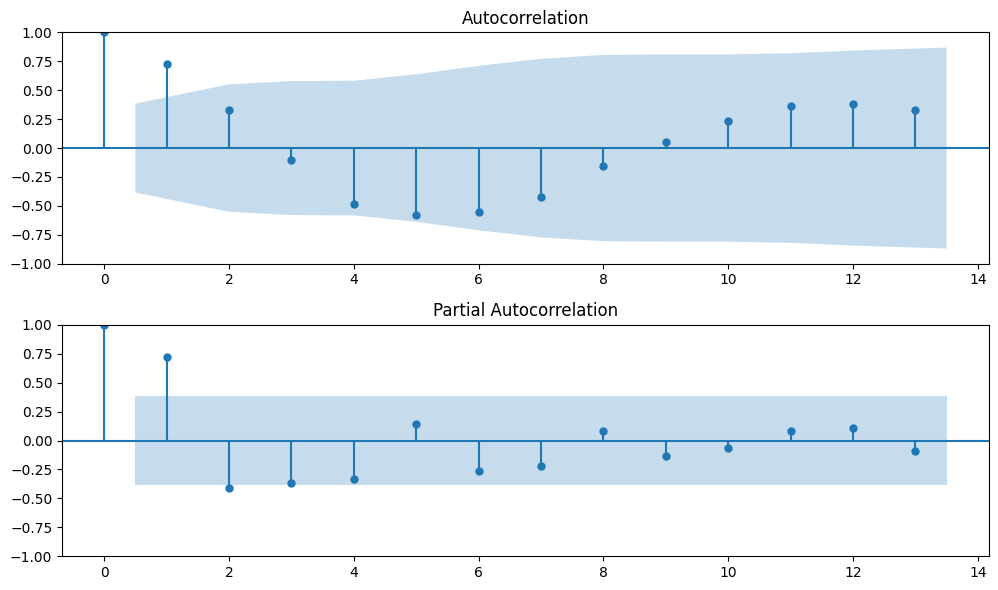

In [163]:
diff_population = train["Population"].diff().dropna()

fig, ax = plt.subplots(2, 1, figsize=(10, 6))
plot_acf(diff_population.dropna(), ax=ax[0])
plot_pacf(diff_population.dropna(), ax=ax[1])
plt.tight_layout()
plt.show()

In [164]:
bounds_map = {
    "Population": {"p_min": 0, "p_max": 1, "d_min": 1, "d_max": 1, "q_min": 0, "q_max": 1, "P_min": 0, "P_max": 0, "D_min": 0, "D_max": 0, "Q_min": 0, "Q_max": 0},
}

labels = LABEL_COLS

train_sarima = train.set_index("Date")[labels].apply(pd.to_numeric, errors="coerce").sort_index()
test_sarima = test.set_index("Date")[labels].apply(pd.to_numeric, errors="coerce").sort_index()

# Population is annual, so use annual-start frequency.
train_sarima = train_sarima.asfreq("YS")
test_sarima = test_sarima.asfreq("YS")
train_sarima = train_sarima.ffill().bfill()
test_sarima = test_sarima.ffill().bfill()

test_index = pd.to_datetime(test_sarima.index)
forecasts_df = pd.DataFrame(index=test_index)
fitted_models = {}
all_best_dfs = []
all_trial_dfs = []

for label in labels:
    lbl_best, lbl_trials, lbl_forecasts, lbl_models = multitarget_sarima(
        train_df=train_sarima,
        test_df=test_sarima,
        exog_train=None,
        exog_test=None,
        labels=[label],
        bounds_map=bounds_map,
        seasonal_period=12,
        verbose=True,
        n_jobs=1,
    )

    all_best_dfs.append(lbl_best)
    all_trial_dfs.append(lbl_trials)

    lbl_forecasts = lbl_forecasts.copy()
    lbl_forecasts.index = pd.to_datetime(lbl_forecasts.index)

    for col in lbl_forecasts.columns:
        aligned = lbl_forecasts[col].reindex(test_index)
        forecasts_df[col] = aligned.values

    fitted_models.update(lbl_models)

best_models_df = pd.concat(all_best_dfs)
all_trials_df = pd.concat(all_trial_dfs, ignore_index=True)

display(best_models_df)
display(forecasts_df.head())

[Population] candidates: 4


,Best_Order,Best_Seasonal_Order,Best_AIC,MAE,RMSE,MAPE_pct
Target,,,,,,
Population,"(1, 1, 1)","(0, 0, 0, 12)",630.524617,488515.164446,690969.895283,0.428314


,Population
Date,
2019-01-01,1.094936e+08
2020-01-01,1.108580e+08
2021-01-01,1.122129e+08
2022-01-01,1.135584e+08
2023-01-01,1.148945e+08


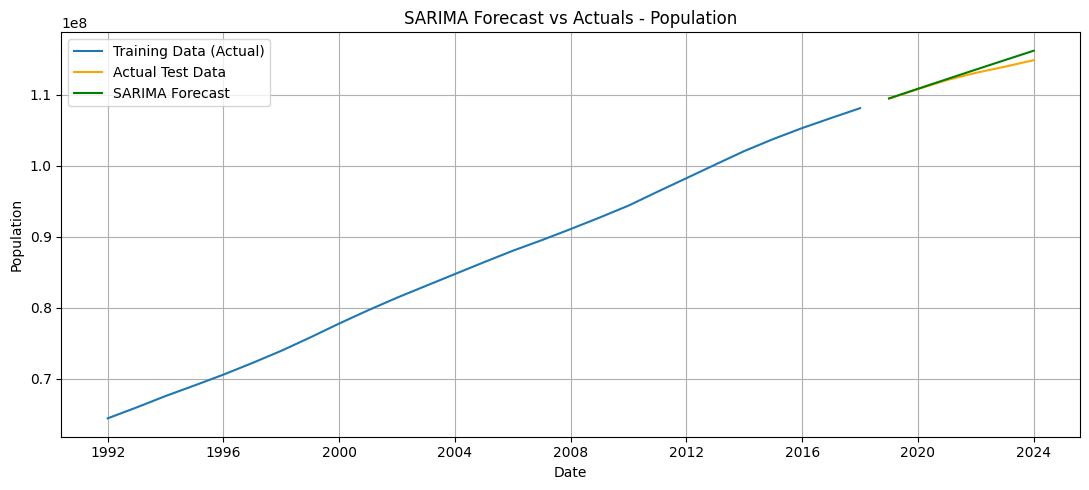

In [165]:
train_eval = train.set_index("Date").copy()
test_eval = test.set_index("Date").copy()

train_eval.index = pd.to_datetime(train_eval.index)
test_eval.index = pd.to_datetime(test_eval.index)

labels_to_plot = [
    lbl for lbl in labels
    if lbl in train_eval.columns and lbl in test_eval.columns and lbl in forecasts_df.columns
]

if not labels_to_plot:
    raise ValueError("No matching labels found across train/test/forecasts_df.")

for lbl in labels_to_plot:
    plt.figure(figsize=(11, 5))
    plt.plot(train_eval.index, train_eval[lbl], label="Training Data (Actual)")
    plt.plot(test_eval.index, test_eval[lbl], label="Actual Test Data", color="orange")
    plt.plot(forecasts_df.index, forecasts_df[lbl], label="SARIMA Forecast", color="green")
    plt.title(f"SARIMA Forecast vs Actuals - {lbl}")
    plt.xlabel("Date")
    plt.ylabel(lbl)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    

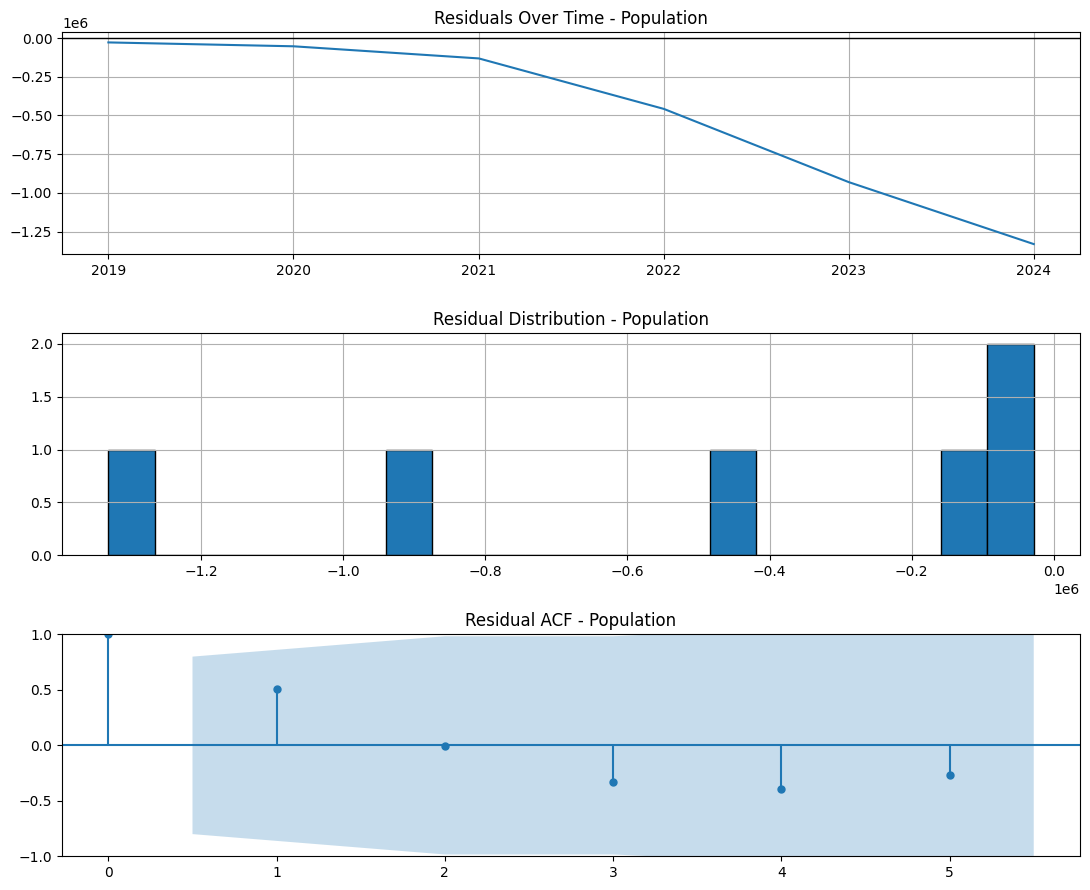

,n_obs,Mean Residual,Std Residual,Ljung-Box p-value (lag 5),No Residual Autocorr (5%),Jarque-Bera p-value,Residual Normal (5%)
Variable,,,,,,,
Population,6,-488515.164446,535304.395978,0.041726,False,0.687162,True


In [166]:
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import jarque_bera

residual_records = []
residuals_df = pd.DataFrame(index=forecasts_df.index)

test_actual = test.set_index("Date").copy()
test_actual.index = pd.to_datetime(test_actual.index)

diag_labels = [
    lbl for lbl in labels
    if lbl in test_actual.columns and lbl in forecasts_df.columns
]

if not diag_labels:
    raise ValueError("No matching labels found for residual diagnostics.")

for lbl in diag_labels:
    actual = pd.to_numeric(test_actual[lbl], errors="coerce")
    pred = pd.to_numeric(forecasts_df[lbl], errors="coerce")

    resid = (actual - pred).dropna()
    residuals_df[lbl] = resid.reindex(residuals_df.index)

    max_valid_lag = min(12, max(1, len(resid) - 1))
    lb_df = acorr_ljungbox(resid, lags=[max_valid_lag], return_df=True)
    jb_stat, jb_p = jarque_bera(resid)

    residual_records.append({
        "Variable": lbl,
        "n_obs": len(resid),
        "Mean Residual": resid.mean(),
        "Std Residual": resid.std(ddof=1),
        f"Ljung-Box p-value (lag {max_valid_lag})": lb_df["lb_pvalue"].iloc[0],
        "No Residual Autocorr (5%)": lb_df["lb_pvalue"].iloc[0] > 0.05,
        "Jarque-Bera p-value": jb_p,
        "Residual Normal (5%)": jb_p > 0.05,
    })

    fig, ax = plt.subplots(3, 1, figsize=(11, 9))
    ax[0].plot(resid.index, resid.values)
    ax[0].axhline(0, color="black", linewidth=1)
    ax[0].set_title(f"Residuals Over Time - {lbl}")
    ax[0].grid(True)

    ax[1].hist(resid.values, bins=20, edgecolor="black")
    ax[1].set_title(f"Residual Distribution - {lbl}")
    ax[1].grid(True)

    plot_acf(resid, ax=ax[2], lags=min(24, max_valid_lag))
    ax[2].set_title(f"Residual ACF - {lbl}")

    plt.tight_layout()
    plt.show()

residual_diagnostics_df = pd.DataFrame(residual_records).set_index("Variable")
residual_diagnostics_df

In [167]:
# Evaluate test-set forecast errors per label.
metrics_records = []

test_eval = test.set_index("Date").copy()
test_eval.index = pd.to_datetime(test_eval.index)

metric_labels = [
    lbl for lbl in labels
    if lbl in test_eval.columns and lbl in forecasts_df.columns
]

for lbl in metric_labels:
    y_true = pd.to_numeric(test_eval[lbl], errors="coerce")
    y_pred = pd.to_numeric(forecasts_df[lbl], errors="coerce")

    comp = pd.concat([y_true, y_pred], axis=1, keys=["actual", "forecast"]).dropna()
    a = comp["actual"]
    f = comp["forecast"]
    err = a - f

    mae = np.mean(np.abs(err))
    rmse = np.sqrt(np.mean(err**2))

    mape = np.nan
    nz = a != 0
    if nz.any():
        mape = np.mean(np.abs((a[nz] - f[nz]) / a[nz])) * 100

    smape_denom = np.abs(a) + np.abs(f)
    smape_mask = smape_denom != 0
    smape = np.nan
    if smape_mask.any():
        smape = np.mean(2 * np.abs(a[smape_mask] - f[smape_mask]) / smape_denom[smape_mask]) * 100

    metrics_records.append({
        "Variable": lbl,
        "n_obs": len(comp),
        "MAE": mae,
        "RMSE": rmse,
        "MAPE_pct": mape,
        "sMAPE_pct": smape,
        "Mean_Error(actual-forecast)": err.mean(),
        "Mean_Abs_Error": np.mean(np.abs(err)),
    })

test_metrics_df = pd.DataFrame(metrics_records).set_index("Variable")
test_metrics_df

,n_obs,MAE,RMSE,MAPE_pct,sMAPE_pct,Mean_Error(actual-forecast),Mean_Abs_Error
Variable,,,,,,,
Population,6,488515.164446,690969.895283,0.428314,0.426501,-488515.164446,488515.164446


In [168]:
import ast
from statsmodels.tsa.statespace.sarimax import SARIMAX

full_df = df[labels].apply(pd.to_numeric, errors="coerce").dropna().copy()
full_df.index = pd.to_datetime(full_df.index).to_period("Y").to_timestamp()
full_df = full_df.groupby(full_df.index).last().sort_index().asfreq("YS")
full_df = full_df.ffill().bfill()

forecast_years = [2025, 2026]
future_index = pd.to_datetime([f"{year}-12-01" for year in forecast_years])
forecast_start = pd.Timestamp("2025-01-01")

future_forecasts = pd.DataFrame(index=future_index)
future_models = {}

for lbl in labels:
    order = best_models_df.loc[lbl, "Best_Order"]
    seasonal_order = best_models_df.loc[lbl, "Best_Seasonal_Order"]

    if isinstance(order, str):
        order = ast.literal_eval(order)
    if isinstance(seasonal_order, str):
        seasonal_order = ast.literal_eval(seasonal_order)

    series = full_df.loc[full_df.index < forecast_start, lbl].dropna()
    if series.empty:
        raise ValueError(f"No training history available before {forecast_start.date()} for {lbl}.")

    model = SARIMAX(
        series,
        order=tuple(order),
        seasonal_order=tuple(seasonal_order),
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    fit = model.fit(disp=False)

    pred = fit.get_forecast(steps=len(forecast_years)).predicted_mean
    pred.index = future_index

    future_forecasts[lbl] = pred.values
    future_models[lbl] = fit

future_forecasts

,Population
2025-12-01,1.158070e+08
2026-12-01,1.167103e+08


## Quarterly GDP

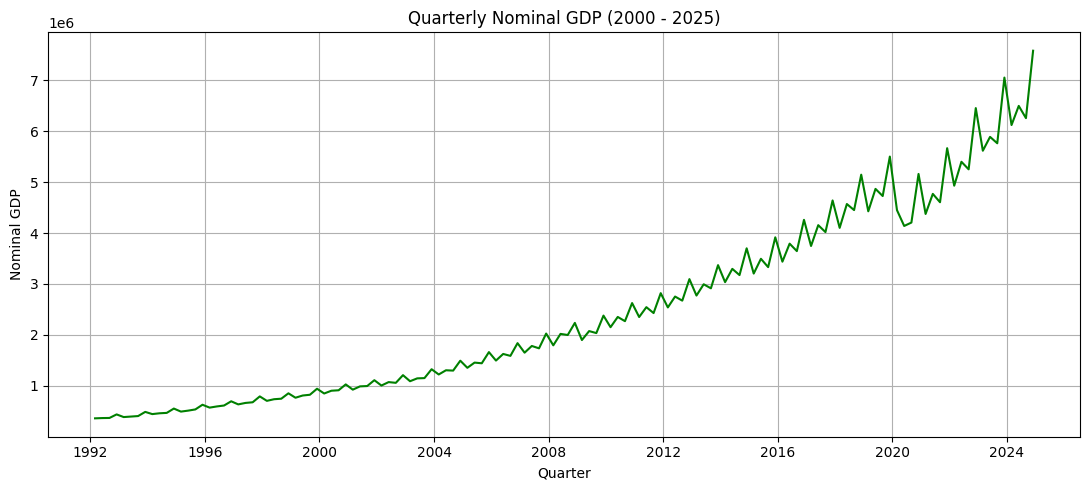

In [169]:
cols = ["Nominal GDP"]

use_cols = [c for c in cols if c in df.columns]
if not use_cols:
    raise ValueError("Requested columns are not present in df.")

df_clean = df[use_cols].copy()
df_clean["Nominal GDP"] = pd.to_numeric(df_clean["Nominal GDP"], errors="coerce")
df_clean = df_clean.dropna(subset=["Nominal GDP"])
if df_clean.empty:
    raise ValueError("No rows left after dropping NaN values in Nominal GDP.")

# Anchor quarterly dates to the first day of the quarter-ending month: Mar, Jun, Sep, Dec.
quarter_index = pd.to_datetime(df_clean.index).to_period("Q")
df_clean.index = quarter_index.asfreq("M", how="end").to_timestamp()
df_clean = df_clean.groupby(df_clean.index).last().sort_index().asfreq("QS-MAR")
df_clean = df_clean.ffill().bfill()

test_num = int(len(df_clean) * 0.20)
train_size = len(df_clean) - test_num

train = df_clean.iloc[:train_size].reset_index().copy()
test = df_clean.iloc[train_size:].reset_index().copy()
train = train.rename(columns={"index": "Date"})
test = test.rename(columns={"index": "Date"})

train_plot = train.set_index("Date")
test_plot = test.set_index("Date")

for col in use_cols:
    plt.figure(figsize=(11, 5))
    plt.plot(df_clean.index, df_clean[col], color="green", linewidth=1.5)
    plt.title(f"Quarterly {col} (2000 - 2025)")
    plt.xlabel("Quarter")
    plt.ylabel(col)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [170]:
LABEL_COLS = ["Nominal GDP"]

records = []

for x in LABEL_COLS:
    s = pd.to_numeric(train[x], errors="coerce")

    level = adfuller(s.dropna(), autolag="AIC")
    first_diff = adfuller(s.diff().dropna(), autolag="AIC")
    second_diff = adfuller(s.diff().diff().dropna(), autolag="AIC")
    seasonal_diff = adfuller(s.diff(12).dropna(), autolag="AIC")
    seasonal_double_diff = adfuller(s.diff().diff(12).dropna(), autolag="AIC")

    records.append({
        "Variable": x,
        "Level p-value": round(level[1], 4),
        "Level Stationary": level[1] < 0.05,
        "First Diff p-value": round(first_diff[1], 4),
        "First Diff Stationary": first_diff[1] < 0.05,
        "Second Diff p-value": round(second_diff[1], 4),
        "Second Diff Stationary": second_diff[1] < 0.05,
        "Seasonal Diff p-value": round(seasonal_diff[1], 4),
        "Seasonal Diff Stationary": seasonal_diff[1] < 0.05,
        "Seasonal Double Diff p-value": round(seasonal_double_diff[1], 4),
        "Seasonal Double Diff Stationary": seasonal_double_diff[1] < 0.05,
    })

stationarity_df = pd.DataFrame(records).set_index("Variable")
stationarity_df

,Level p-value,Level Stationary,First Diff p-value,First Diff Stationary,Second Diff p-value,Second Diff Stationary,Seasonal Diff p-value,Seasonal Diff Stationary,Seasonal Double Diff p-value,Seasonal Double Diff Stationary
Variable,,,,,,,,,,
Nominal GDP,1.0,False,0.9822,False,0.0,True,0.9985,False,0.1871,False


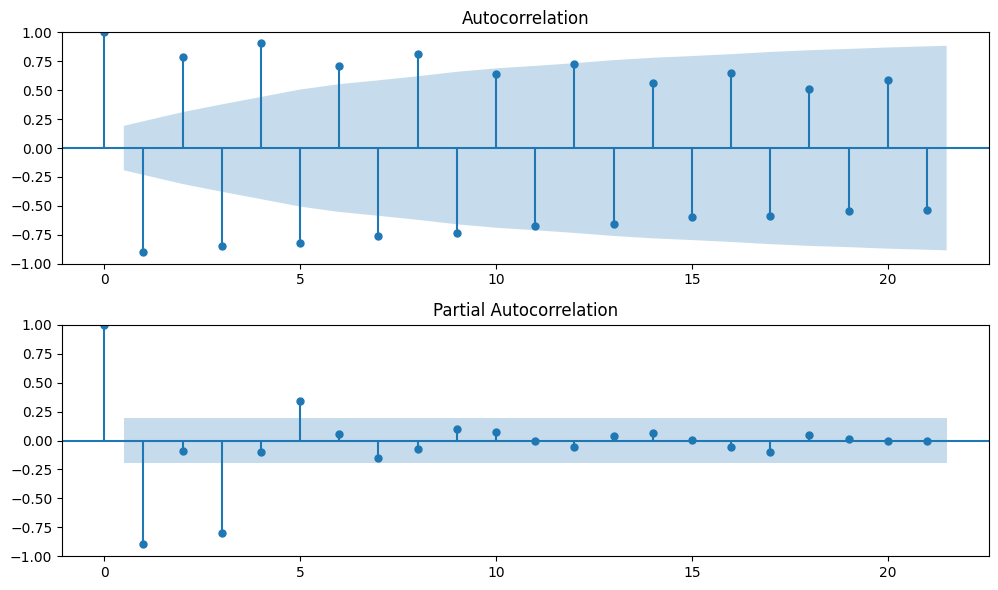

In [171]:
diff_gdp = train["Nominal GDP"].diff().diff().dropna()

fig, ax = plt.subplots(2, 1, figsize=(10, 6))
plot_acf(diff_gdp, ax=ax[0])
plot_pacf(diff_gdp, ax=ax[1])
plt.tight_layout()
plt.show()

In [172]:
bounds_map = {
    "Nominal GDP": {"p_min": 0, "p_max": 1, "d_min": 2, "d_max": 2, "q_min": 0, "q_max": 3, "P_min": 0, "P_max": 2, "D_min": 0, "D_max": 0, "Q_min": 0, "Q_max": 0},
}

labels = LABEL_COLS

train_sarima = train.set_index("Date")[labels].apply(pd.to_numeric, errors="coerce").sort_index()
test_sarima = test.set_index("Date")[labels].apply(pd.to_numeric, errors="coerce").sort_index()

# Nominal GDP is quarterly with Mar/Jun/Sep/Dec anchors.
train_sarima = train_sarima.asfreq("QS-MAR")
test_sarima = test_sarima.asfreq("QS-MAR")
train_sarima = train_sarima.ffill().bfill()
test_sarima = test_sarima.ffill().bfill()

test_index = pd.to_datetime(test_sarima.index)
forecasts_df = pd.DataFrame(index=test_index)
fitted_models = {}
all_best_dfs = []
all_trial_dfs = []

for label in labels:
    lbl_best, lbl_trials, lbl_forecasts, lbl_models = multitarget_sarima(
        train_df=train_sarima,
        test_df=test_sarima,
        exog_train=None,
        exog_test=None,
        labels=[label],
        bounds_map=bounds_map,
        seasonal_period=4,
        verbose=True,
        n_jobs=1,
    )

    all_best_dfs.append(lbl_best)
    all_trial_dfs.append(lbl_trials)

    lbl_forecasts = lbl_forecasts.copy()
    lbl_forecasts.index = pd.to_datetime(lbl_forecasts.index)

    for col in lbl_forecasts.columns:
        aligned = lbl_forecasts[col].reindex(test_index)
        forecasts_df[col] = aligned.values

    fitted_models.update(lbl_models)

best_models_df = pd.concat(all_best_dfs)
all_trials_df = pd.concat(all_trial_dfs, ignore_index=True)

display(best_models_df)
display(forecasts_df.head())

Nominal GDP grid:   0%|          | 0/8 [00:00<?, ?it/s]

[Nominal GDP] candidates: 24


,Best_Order,Best_Seasonal_Order,Best_AIC,MAE,RMSE,MAPE_pct
Target,,,,,,
Nominal GDP,"(0, 2, 0)","(2, 0, 0, 4)",2317.681182,1.842846e+06,2.187091e+06,32.830466


,Nominal GDP
Date,
2018-09-01,4.440632e+06
2018-12-01,5.153869e+06
2019-03-01,4.586113e+06
2019-06-01,5.118698e+06
2019-09-01,4.999718e+06


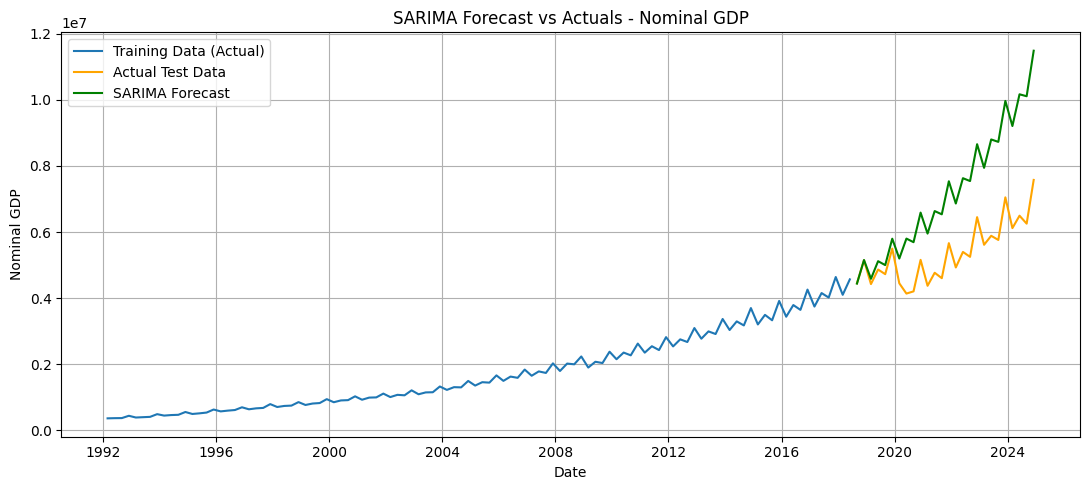

In [173]:
train_eval = train.set_index("Date").copy()
test_eval = test.set_index("Date").copy()

train_eval.index = pd.to_datetime(train_eval.index)
test_eval.index = pd.to_datetime(test_eval.index)

labels_to_plot = [
    lbl for lbl in labels
    if lbl in train_eval.columns and lbl in test_eval.columns and lbl in forecasts_df.columns
]

if not labels_to_plot:
    raise ValueError("No matching labels found across train/test/forecasts_df.")

for lbl in labels_to_plot:
    plt.figure(figsize=(11, 5))
    plt.plot(train_eval.index, train_eval[lbl], label="Training Data (Actual)")
    plt.plot(test_eval.index, test_eval[lbl], label="Actual Test Data", color="orange")
    plt.plot(forecasts_df.index, forecasts_df[lbl], label="SARIMA Forecast", color="green")
    plt.title(f"SARIMA Forecast vs Actuals - {lbl}")
    plt.xlabel("Date")
    plt.ylabel(lbl)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    

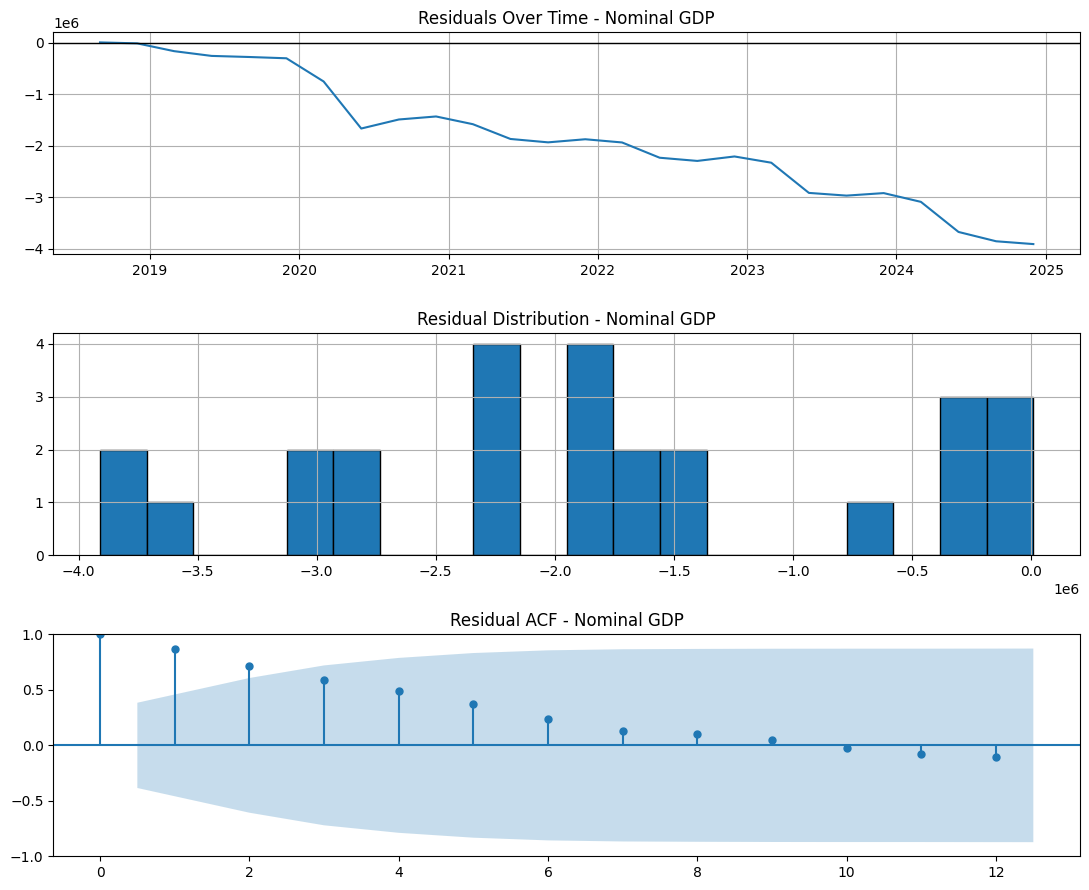

,n_obs,Mean Residual,Std Residual,Ljung-Box p-value (lag 12),No Residual Autocorr (5%),Jarque-Bera p-value,Residual Normal (5%)
Variable,,,,,,,
Nominal GDP,26,-1.842109e+06,1.202333e+06,2.516734e-09,False,0.618602,True


In [174]:
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import jarque_bera

residual_records = []
residuals_df = pd.DataFrame(index=forecasts_df.index)

test_actual = test.set_index("Date").copy()
test_actual.index = pd.to_datetime(test_actual.index)

diag_labels = [
    lbl for lbl in labels
    if lbl in test_actual.columns and lbl in forecasts_df.columns
]

if not diag_labels:
    raise ValueError("No matching labels found for residual diagnostics.")

for lbl in diag_labels:
    actual = pd.to_numeric(test_actual[lbl], errors="coerce")
    pred = pd.to_numeric(forecasts_df[lbl], errors="coerce")

    resid = (actual - pred).dropna()
    residuals_df[lbl] = resid.reindex(residuals_df.index)

    max_valid_lag = min(12, max(1, len(resid) - 1))
    lb_df = acorr_ljungbox(resid, lags=[max_valid_lag], return_df=True)
    jb_stat, jb_p = jarque_bera(resid)

    residual_records.append({
        "Variable": lbl,
        "n_obs": len(resid),
        "Mean Residual": resid.mean(),
        "Std Residual": resid.std(ddof=1),
        f"Ljung-Box p-value (lag {max_valid_lag})": lb_df["lb_pvalue"].iloc[0],
        "No Residual Autocorr (5%)": lb_df["lb_pvalue"].iloc[0] > 0.05,
        "Jarque-Bera p-value": jb_p,
        "Residual Normal (5%)": jb_p > 0.05,
    })

    fig, ax = plt.subplots(3, 1, figsize=(11, 9))
    ax[0].plot(resid.index, resid.values)
    ax[0].axhline(0, color="black", linewidth=1)
    ax[0].set_title(f"Residuals Over Time - {lbl}")
    ax[0].grid(True)

    ax[1].hist(resid.values, bins=20, edgecolor="black")
    ax[1].set_title(f"Residual Distribution - {lbl}")
    ax[1].grid(True)

    plot_acf(resid, ax=ax[2], lags=min(24, max_valid_lag))
    ax[2].set_title(f"Residual ACF - {lbl}")

    plt.tight_layout()
    plt.show()

residual_diagnostics_df = pd.DataFrame(residual_records).set_index("Variable")
residual_diagnostics_df

In [175]:
# Evaluate test-set forecast errors per label.
metrics_records = []

test_eval = test.set_index("Date").copy()
test_eval.index = pd.to_datetime(test_eval.index)

metric_labels = [
    lbl for lbl in labels
    if lbl in test_eval.columns and lbl in forecasts_df.columns
]

for lbl in metric_labels:
    y_true = pd.to_numeric(test_eval[lbl], errors="coerce")
    y_pred = pd.to_numeric(forecasts_df[lbl], errors="coerce")

    comp = pd.concat([y_true, y_pred], axis=1, keys=["actual", "forecast"]).dropna()
    a = comp["actual"]
    f = comp["forecast"]
    err = a - f

    mae = np.mean(np.abs(err))
    rmse = np.sqrt(np.mean(err**2))

    mape = np.nan
    nz = a != 0
    if nz.any():
        mape = np.mean(np.abs((a[nz] - f[nz]) / a[nz])) * 100

    smape_denom = np.abs(a) + np.abs(f)
    smape_mask = smape_denom != 0
    smape = np.nan
    if smape_mask.any():
        smape = np.mean(2 * np.abs(a[smape_mask] - f[smape_mask]) / smape_denom[smape_mask]) * 100

    metrics_records.append({
        "Variable": lbl,
        "n_obs": len(comp),
        "MAE": mae,
        "RMSE": rmse,
        "MAPE_pct": mape,
        "sMAPE_pct": smape,
        "Mean_Error(actual-forecast)": err.mean(),
        "Mean_Abs_Error": np.mean(np.abs(err)),
    })

test_metrics_df = pd.DataFrame(metrics_records).set_index("Variable")
test_metrics_df

,n_obs,MAE,RMSE,MAPE_pct,sMAPE_pct,Mean_Error(actual-forecast),Mean_Abs_Error
Variable,,,,,,,
Nominal GDP,26,1.842846e+06,2.187091e+06,32.830466,27.067026,-1.842109e+06,1.842846e+06


In [176]:
import ast
from statsmodels.tsa.statespace.sarimax import SARIMAX

full_df = df[labels].apply(pd.to_numeric, errors="coerce").dropna().copy()
quarter_index = pd.to_datetime(full_df.index).to_period("Q")
full_df.index = quarter_index.asfreq("M", how="end").to_timestamp()
full_df = full_df.groupby(full_df.index).last().sort_index().asfreq("QS-MAR")
full_df = full_df.ffill().bfill()

future_index = pd.date_range("2025-03-01", "2026-12-01", freq="QS-MAR")
forecast_start = future_index.min()

future_forecasts = pd.DataFrame(index=future_index)
future_models = {}

for lbl in labels:
    order = best_models_df.loc[lbl, "Best_Order"]
    seasonal_order = best_models_df.loc[lbl, "Best_Seasonal_Order"]

    if isinstance(order, str):
        order = ast.literal_eval(order)
    if isinstance(seasonal_order, str):
        seasonal_order = ast.literal_eval(seasonal_order)

    series = full_df.loc[full_df.index < forecast_start, lbl].dropna()
    if series.empty:
        raise ValueError(f"No training history available before {forecast_start.date()} for {lbl}.")

    model = SARIMAX(
        series,
        order=tuple(order),
        seasonal_order=tuple(seasonal_order),
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    fit = model.fit(disp=False)

    pred = fit.get_forecast(steps=len(future_index)).predicted_mean
    pred.index = future_index

    future_forecasts[lbl] = pred.values
    future_models[lbl] = fit

future_forecasts

,Nominal GDP
2025-03-01,6.517254e+06
2025-06-01,6.816423e+06
2025-09-01,6.534055e+06
2025-12-01,7.920645e+06
2026-03-01,6.732610e+06
2026-06-01,7.032332e+06
2026-09-01,6.668735e+06
2026-12-01,8.111814e+06


## Final

In [177]:
import ast
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sarima import multitarget_sarima

# ------------------------------
# 1) Monthly macro forecasts
# ------------------------------
macro_labels = ["Inflation", "USDPHP", "Imports_PHPMN", "Exports_PHPMN"]
macro_bounds = {
    "Inflation": {"p_min": 0, "p_max": 1, "d_min": 1, "d_max": 1, "q_min": 0, "q_max": 2, "P_min": 0, "P_max": 1, "D_min": 0, "D_max": 1, "Q_min": 0, "Q_max": 1},
    "USDPHP": {"p_min": 0, "p_max": 1, "d_min": 1, "d_max": 1, "q_min": 0, "q_max": 1, "P_min": 0, "P_max": 1, "D_min": 0, "D_max": 1, "Q_min": 0, "Q_max": 1},
    "Imports_PHPMN": {"p_min": 0, "p_max": 1, "d_min": 2, "d_max": 2, "q_min": 0, "q_max": 1, "P_min": 0, "P_max": 1, "D_min": 0, "D_max": 1, "Q_min": 0, "Q_max": 1},
    "Exports_PHPMN": {"p_min": 0, "p_max": 1, "d_min": 1, "d_max": 1, "q_min": 0, "q_max": 1, "P_min": 0, "P_max": 1, "D_min": 0, "D_max": 1, "Q_min": 0, "Q_max": 1},
}

macro_full = df[macro_labels].apply(pd.to_numeric, errors="coerce").sort_index().asfreq("MS")
macro_full = macro_full.interpolate(method="time").ffill().bfill()

macro_test_n = int(len(macro_full) * 0.20)
macro_train = macro_full.iloc[:-macro_test_n]
macro_test = macro_full.iloc[-macro_test_n:]

macro_best, _, _, _ = multitarget_sarima(
    train_df=macro_train,
    test_df=macro_test,
    exog_train=None,
    exog_test=None,
    labels=macro_labels,
    bounds_map=macro_bounds,
    seasonal_period=12,
    verbose=False,
    n_jobs=1,
)

macro_future_index = pd.date_range("2025-01-01", "2026-12-01", freq="MS")
macro_forecast_start = pd.Timestamp("2025-01-01")
macro_future = pd.DataFrame(index=macro_future_index)

for lbl in macro_labels:
    order = macro_best.loc[lbl, "Best_Order"]
    seasonal_order = macro_best.loc[lbl, "Best_Seasonal_Order"]

    if isinstance(order, str):
        order = ast.literal_eval(order)
    if isinstance(seasonal_order, str):
        seasonal_order = ast.literal_eval(seasonal_order)

    series = macro_full.loc[macro_full.index < macro_forecast_start, lbl].dropna()

    model = SARIMAX(
        series,
        order=tuple(order),
        seasonal_order=tuple(seasonal_order),
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    fit = model.fit(disp=False)
    pred = fit.get_forecast(steps=len(macro_future_index)).predicted_mean
    pred.index = macro_future_index
    macro_future[lbl] = pred.values

# ------------------------------
# 2) Annual population forecasts
# ------------------------------
pop_labels = ["Population"]
pop_bounds = {
    "Population": {"p_min": 0, "p_max": 1, "d_min": 1, "d_max": 1, "q_min": 0, "q_max": 1, "P_min": 0, "P_max": 0, "D_min": 0, "D_max": 0, "Q_min": 0, "Q_max": 0},
}

pop_full = df[pop_labels].apply(pd.to_numeric, errors="coerce").dropna().copy()
pop_full.index = pd.to_datetime(pop_full.index).to_period("Y").to_timestamp()
pop_full = pop_full.groupby(pop_full.index).last().sort_index().asfreq("YS")
pop_full = pop_full.ffill().bfill()

pop_test_n = int(len(pop_full) * 0.20)
pop_train = pop_full.iloc[:-pop_test_n]
pop_test = pop_full.iloc[-pop_test_n:]

pop_best, _, _, _ = multitarget_sarima(
    train_df=pop_train,
    test_df=pop_test,
    exog_train=None,
    exog_test=None,
    labels=pop_labels,
    bounds_map=pop_bounds,
    seasonal_period=12,
    verbose=False,
    n_jobs=1,
)

pop_future_index = pd.to_datetime(["2025-12-01", "2026-12-01"])
pop_forecast_start = pd.Timestamp("2025-01-01")
pop_future = pd.DataFrame(index=pop_future_index)

for lbl in pop_labels:
    order = pop_best.loc[lbl, "Best_Order"]
    seasonal_order = pop_best.loc[lbl, "Best_Seasonal_Order"]

    if isinstance(order, str):
        order = ast.literal_eval(order)
    if isinstance(seasonal_order, str):
        seasonal_order = ast.literal_eval(seasonal_order)

    series = pop_full.loc[pop_full.index < pop_forecast_start, lbl].dropna()

    model = SARIMAX(
        series,
        order=tuple(order),
        seasonal_order=tuple(seasonal_order),
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    fit = model.fit(disp=False)
    pred = fit.get_forecast(steps=len(pop_future_index)).predicted_mean
    pred.index = pop_future_index
    pop_future[lbl] = pred.values

# ------------------------------
# 3) Quarterly nominal GDP forecasts
# ------------------------------
gdp_labels = ["Nominal GDP"]
gdp_bounds = {
    "Nominal GDP": {"p_min": 0, "p_max": 1, "d_min": 2, "d_max": 2, "q_min": 0, "q_max": 3, "P_min": 0, "P_max": 2, "D_min": 0, "D_max": 0, "Q_min": 0, "Q_max": 0},
}

gdp_full = df[gdp_labels].apply(pd.to_numeric, errors="coerce").dropna().copy()
q_index = pd.to_datetime(gdp_full.index).to_period("Q")
gdp_full.index = q_index.asfreq("M", how="end").to_timestamp()
gdp_full = gdp_full.groupby(gdp_full.index).last().sort_index().asfreq("QS-MAR")
gdp_full = gdp_full.ffill().bfill()

gdp_test_n = int(len(gdp_full) * 0.20)
gdp_train = gdp_full.iloc[:-gdp_test_n]
gdp_test = gdp_full.iloc[-gdp_test_n:]

gdp_best, _, _, _ = multitarget_sarima(
    train_df=gdp_train,
    test_df=gdp_test,
    exog_train=None,
    exog_test=None,
    labels=gdp_labels,
    bounds_map=gdp_bounds,
    seasonal_period=4,
    verbose=False,
    n_jobs=1,
)

gdp_future_index = pd.date_range("2025-03-01", "2026-12-01", freq="QS-MAR")
gdp_forecast_start = pd.Timestamp("2025-03-01")
gdp_future = pd.DataFrame(index=gdp_future_index)

for lbl in gdp_labels:
    order = gdp_best.loc[lbl, "Best_Order"]
    seasonal_order = gdp_best.loc[lbl, "Best_Seasonal_Order"]

    if isinstance(order, str):
        order = ast.literal_eval(order)
    if isinstance(seasonal_order, str):
        seasonal_order = ast.literal_eval(seasonal_order)

    series = gdp_full.loc[gdp_full.index < gdp_forecast_start, lbl].dropna()

    model = SARIMAX(
        series,
        order=tuple(order),
        seasonal_order=tuple(seasonal_order),
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    fit = model.fit(disp=False)
    pred = fit.get_forecast(steps=len(gdp_future_index)).predicted_mean
    pred.index = gdp_future_index
    gdp_future[lbl] = pred.values

# ------------------------------
# 4) Combined prediction dataframe (2025-2026)
# ------------------------------
combined_index = pd.date_range("2025-01-01", "2026-12-01", freq="MS")
all_predictions_2025_2026 = pd.DataFrame(index=combined_index)
all_predictions_2025_2026.index.name = "Date"

for col in macro_labels:
    all_predictions_2025_2026[col] = macro_future.reindex(combined_index)[col]

all_predictions_2025_2026["Population"] = pop_future.reindex(combined_index)["Population"]
all_predictions_2025_2026["Nominal GDP"] = gdp_future.reindex(combined_index)["Nominal GDP"]

all_predictions_2025_2026

,Inflation,USDPHP,Imports_PHPMN,Exports_PHPMN,Population,Nominal GDP
Date,,,,,,
2025-01-01,3.280024,58.348728,597897.763623,325901.681553,NaN,NaN
2025-02-01,2.880258,58.169704,548403.687472,320446.314486,NaN,NaN
2025-03-01,2.894092,58.216728,598989.855531,357330.791256,NaN,6.517254e+06
2025-04-01,3.132856,58.150176,577280.412699,320385.636314,NaN,NaN
2025-05-01,3.171199,58.241582,604874.361514,349972.313921,NaN,NaN
2025-06-01,3.453748,58.613525,602155.302239,354269.878959,NaN,6.816423e+06
2025-07-01,3.169028,58.875819,623080.656179,357331.898053,NaN,NaN
2025-08-01,3.559269,59.029679,626558.755083,367225.679082,NaN,NaN
2025-09-01,4.039626,59.319910,629416.882690,374235.213943,NaN,6.534055e+06


In [181]:
# Append all_predictions_2025_2026 to df (update df in-place for next cells)
pred = all_predictions_2025_2026.copy()
pred.index = pd.to_datetime(pred.index)

df.index = pd.to_datetime(df.index)

common_cols = [c for c in pred.columns if c in df.columns]
if not common_cols:
    raise ValueError("No matching columns found between df and all_predictions_2025_2026.")

append_block = pd.DataFrame(index=pred.index, columns=df.columns)
append_block[common_cols] = pred[common_cols]

df = pd.concat([df, append_block], axis=0).sort_index()
# Keep original rows when dates overlap, append only new dates.
df = df[~df.index.duplicated(keep="first")]

df.tail(30)

,Inflation,Population,Imports,Exports,USDPHP,Nominal GDP,TotalTrade,TotalTrade_PHPMN,NominalGDP_disagg,Pop_disagg,Imports_PHPMN,Exports_PHPMN
Date,,,,,,,,,,,,
2024-07-01,4.400000,NaN,11129.79,6251.6,58.484500,NaN,17381.39,1016541.903,2187564.495,113947108.6,650920.203300,365621.700200
2024-08-01,3.300000,NaN,11148.73,6753.4,57.193500,NaN,17902.13,1023885.472,2164754.279,113937356.1,637634.889300,386250.582900
2024-09-01,1.900000,NaN,11362.26,6259.74,56.071300,6254621,17622.0,988088.4486,2036580.066,113929554.1,637096.689100,350991.759500
2024-10-01,2.300000,NaN,12005.74,6191.05,57.300900,NaN,18196.79,1042692.444,2085969.176,113923702.7,687939.707200,354752.736900
2024-11-01,2.500000,NaN,10632.93,5697.41,58.694700,NaN,16330.34,958504.4072,2075700.363,113919801.7,624096.636500,334407.770700
2024-12-01,2.900000,1.148912e+08,9818.51,5672.89,58.448000,7577838,15491.4,905441.3472,2595756.306,115090094.4,573872.272500,331569.074700
2025-01-01,2.900000,NaN,11528.18,6573.54,58.390600,NaN,18101.72,1056970.292,NaN,NaN,673137.347100,383832.944700
2025-02-01,2.100000,NaN,9778.51,6787.17,58.094200,NaN,16565.68,962369.9271,NaN,NaN,568074.715600,394295.211400
2025-03-01,1.800000,NaN,11292.16,6782.69,57.424600,"6,583,459",18074.85,1037941.031,NaN,NaN,648447.771100,389493.260200


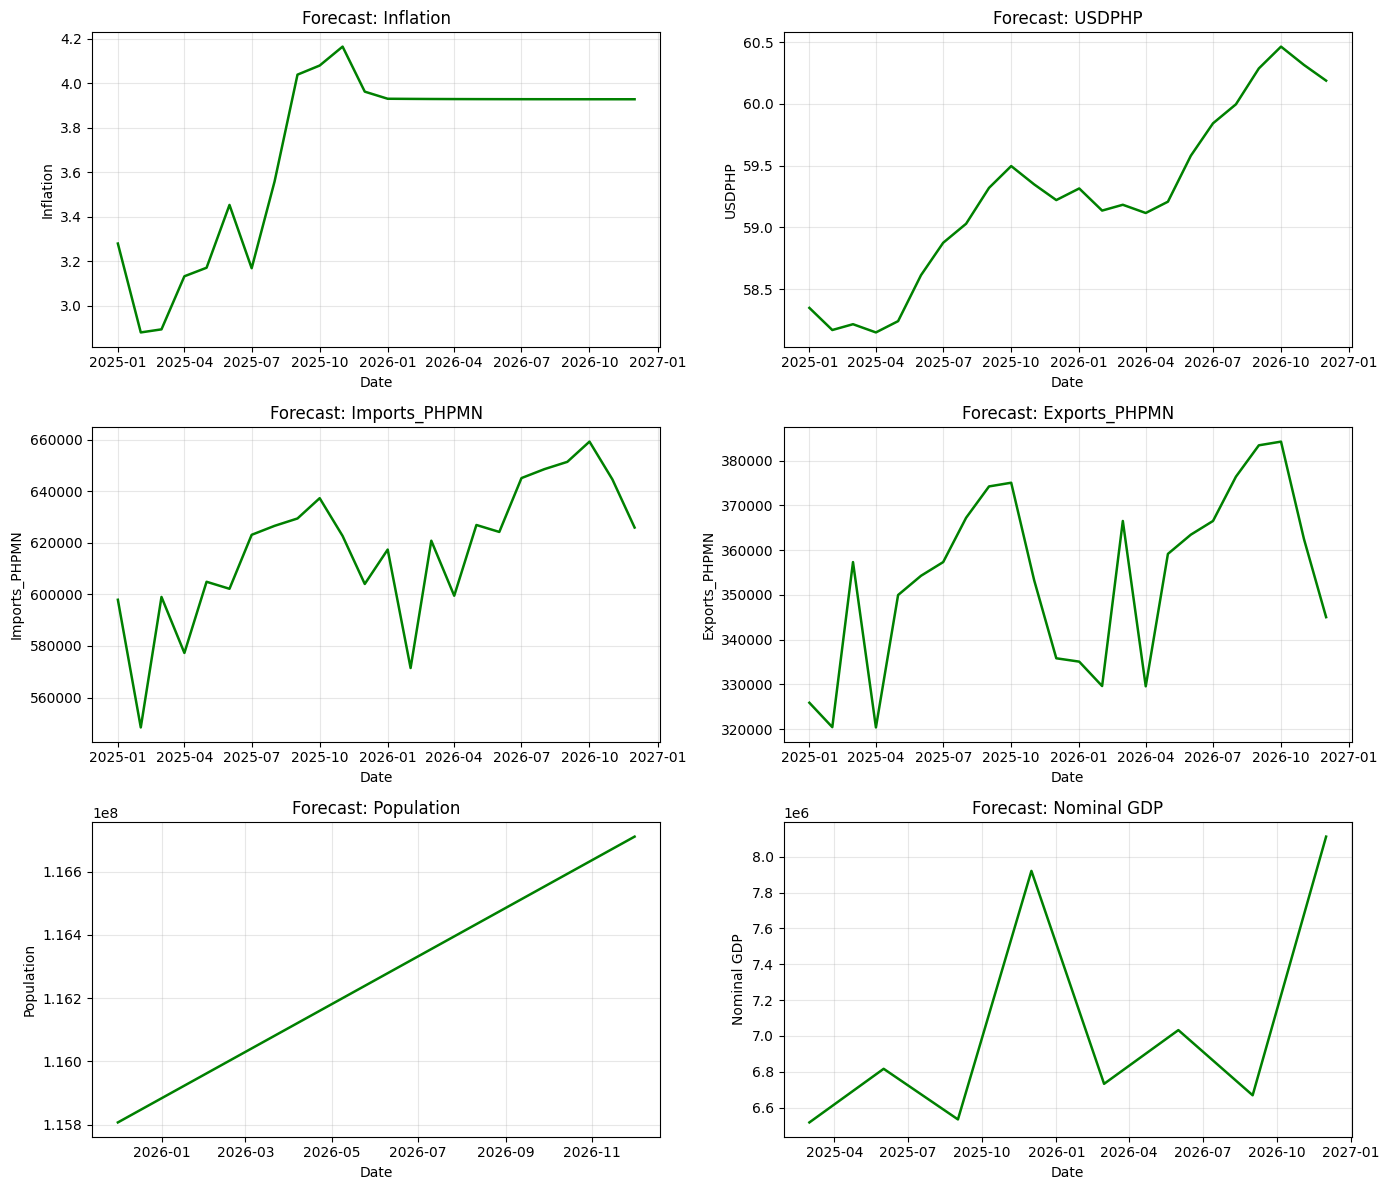

In [182]:
def plot_forecast_df(forecast_df, columns=None, ncols=2, figsize=(14, 10), dropna_each_series=True):
    """Plot forecast columns from a dataframe with a DatetimeIndex.

    Parameters
    ----------
    forecast_df : pd.DataFrame
        Dataframe containing forecast series.
    columns : list[str] | None
        Columns to plot. If None, all columns are plotted.
    ncols : int
        Number of subplot columns.
    figsize : tuple
        Figure size.
    dropna_each_series : bool
        If True, each subplot drops NaN values before plotting.
    """
    if not isinstance(forecast_df, pd.DataFrame):
        raise TypeError("forecast_df must be a pandas DataFrame.")
    if forecast_df.empty:
        raise ValueError("forecast_df is empty.")

    plot_cols = list(forecast_df.columns) if columns is None else [c for c in columns if c in forecast_df.columns]
    if not plot_cols:
        raise ValueError("No valid columns found to plot.")

    data = forecast_df.copy()
    data.index = pd.to_datetime(data.index)

    n = len(plot_cols)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, squeeze=False)
    axes = axes.flatten()

    for i, col in enumerate(plot_cols):
        ax = axes[i]
        s = data[col].copy()
        if dropna_each_series:
            s = s.dropna()

        ax.plot(s.index, s.values, color="green", linewidth=1.8)
        ax.set_title(f"Forecast: {col}")
        ax.set_xlabel("Date")
        ax.set_ylabel(col)
        ax.grid(True, alpha=0.3)

    for j in range(n, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()


# Example usage on your combined forecast dataframe:
plot_forecast_df(all_predictions_2025_2026, ncols=2, figsize=(14, 12))

In [183]:
# Append combined predictions to the original dataframe (without modifying df in-place)
df_base = df.copy()
df_base.index = pd.to_datetime(df_base.index)

pred = all_predictions_2025_2026.copy()
pred.index = pd.to_datetime(pred.index)

common_cols = [c for c in pred.columns if c in df_base.columns]
if not common_cols:
    raise ValueError("No matching columns found between df and all_predictions_2025_2026.")

# Build an append block with the same columns as df.
append_block = pd.DataFrame(index=pred.index, columns=df_base.columns)
append_block[common_cols] = pred[common_cols]

# Append rows and keep original data for duplicate dates.
df_with_predictions = pd.concat([df_base, append_block], axis=0).sort_index()
df_with_predictions = df_with_predictions[~df_with_predictions.index.duplicated(keep="first")]

df_with_predictions.tail(30)

,Inflation,Population,Imports,Exports,USDPHP,Nominal GDP,TotalTrade,TotalTrade_PHPMN,NominalGDP_disagg,Pop_disagg,Imports_PHPMN,Exports_PHPMN
Date,,,,,,,,,,,,
2024-07-01,4.400000,NaN,11129.79,6251.6,58.484500,NaN,17381.39,1016541.903,2187564.495,113947108.6,650920.203300,365621.700200
2024-08-01,3.300000,NaN,11148.73,6753.4,57.193500,NaN,17902.13,1023885.472,2164754.279,113937356.1,637634.889300,386250.582900
2024-09-01,1.900000,NaN,11362.26,6259.74,56.071300,6254621,17622.0,988088.4486,2036580.066,113929554.1,637096.689100,350991.759500
2024-10-01,2.300000,NaN,12005.74,6191.05,57.300900,NaN,18196.79,1042692.444,2085969.176,113923702.7,687939.707200,354752.736900
2024-11-01,2.500000,NaN,10632.93,5697.41,58.694700,NaN,16330.34,958504.4072,2075700.363,113919801.7,624096.636500,334407.770700
2024-12-01,2.900000,1.148912e+08,9818.51,5672.89,58.448000,7577838,15491.4,905441.3472,2595756.306,115090094.4,573872.272500,331569.074700
2025-01-01,3.280024,NaN,NaN,NaN,58.348728,NaN,NaN,NaN,NaN,NaN,597897.763623,325901.681553
2025-02-01,2.100000,NaN,9778.51,6787.17,58.094200,NaN,16565.68,962369.9271,NaN,NaN,568074.715600,394295.211400
2025-03-01,1.800000,NaN,11292.16,6782.69,57.424600,"6,583,459",18074.85,1037941.031,NaN,NaN,648447.771100,389493.260200
